# **Hull-White Calibration and Multi-Measure Valuation**

Vincent GACHON, Martin BELOT, Léo LINOSSIER

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.optimize import minimize
from scipy.optimize import curve_fit
import time

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## **1. Calibration Strategy**

Consider the Hull-White (HW) short-rate model under the risk-neutral measure $\mathbb{Q}$:

$$dr_t = (\theta(t) - ar_t)dt + \sigma dW_t$$

We assume that the parameters $(a, \sigma)$ are identical under the historical measure $\mathbb{P}$ and the risk-neutral measure $\mathbb{Q}$.

Assumptions of the Hull-White (One factor) Model:

- Mean reversion speed is constant
- Volatility is constant

Features:

- Reversion level is time-dependent. 
- The parameter $\theta(t)$ is chosen to make the model consistent with the initial term structure. (In the Vasicek Model, this parameter is constant).

### **1.1. Estimation of Historical Parameters**

In this section, we estimate the mean reversion parameter $a$ and volatility $\sigma$ using a time series of historical short-term interest rates (€STR). We discretize the process and estimate the parameters using both: an AR(1) regression approach and the exact Maximum Likelihood Estimation (MLE) for the Ornstein-Uhlenbeck process. Finally, we compare the two methods and discuss which approach we recommend and why.

First, we retreive ESTR daily data from the ECB database and we format the dataframe to make it suitable for our manipulations.

*Source: ECB, Euro short-term rate, Daily - businessweek, Series key: EST.B.EU000A2X2A25.WT*

In [ ]:
estr = pd.read_csv('../data/ESTR.csv', sep=';', skiprows=6, names=['Date', 'ESTR'])

estr['Date'] = pd.to_datetime(estr['Date'], format='%Y-%m-%d')
estr['ESTR'] = estr['ESTR'].replace('-', np.nan)  
estr['ESTR'] = estr['ESTR'].str.replace(',', '.').astype(float)
estr['ESTR'] = estr['ESTR'] / 100
estr = estr.sort_values('Date').reset_index(drop=True)
estr['ESTR'] = estr['ESTR'].interpolate(method='linear')

estr.head()

,Date,ESTR
0,2019-10-01,-0.00549
1,2019-10-02,-0.00551
2,2019-10-03,-0.00555
3,2019-10-04,-0.00553
4,2019-10-07,-0.00554


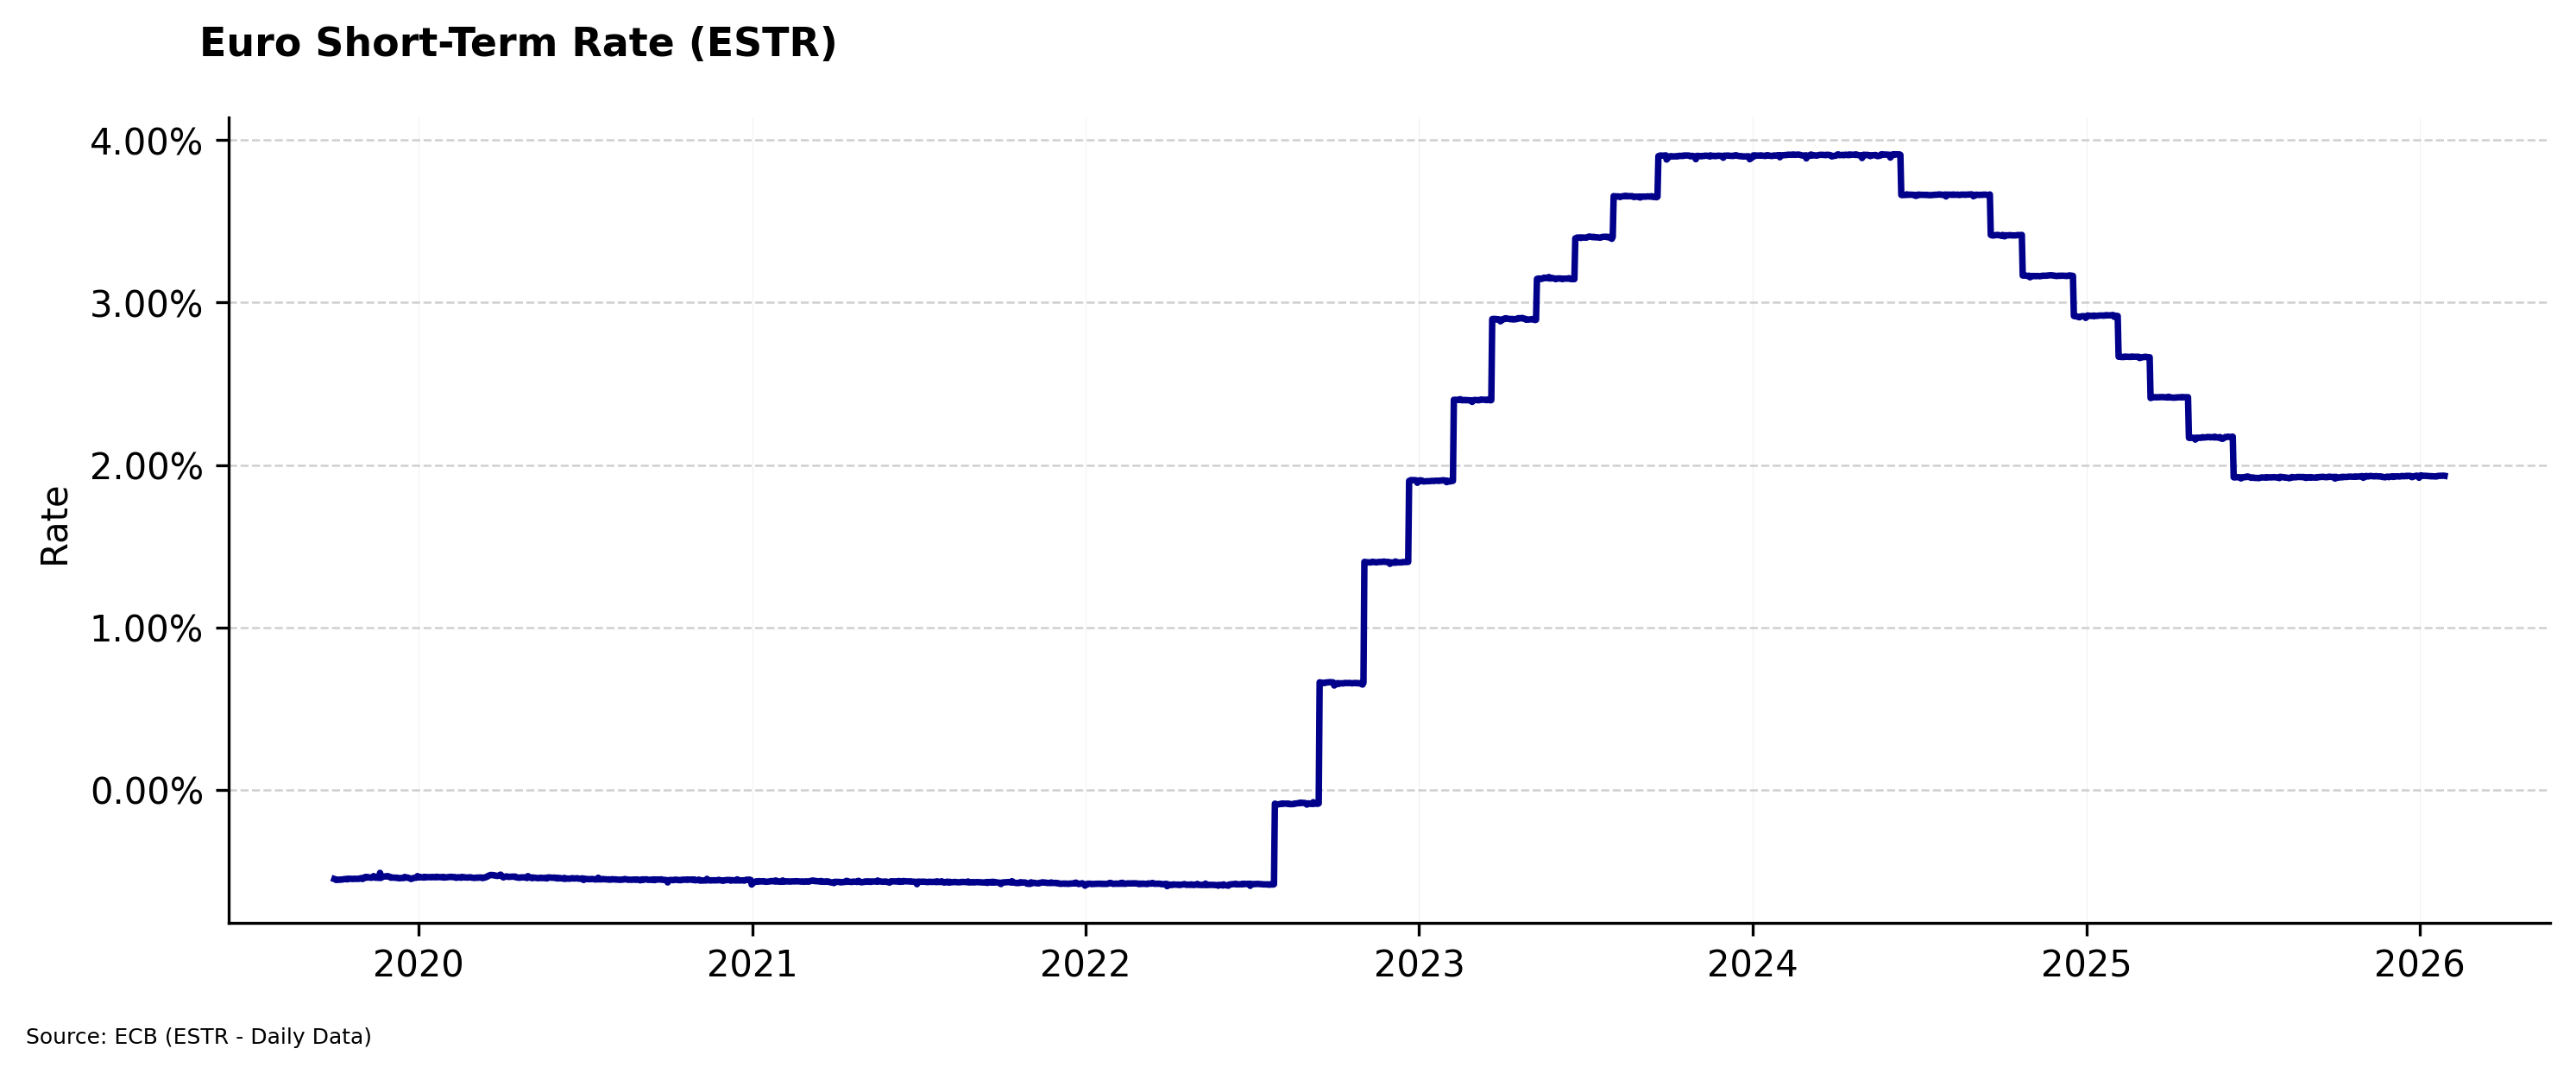

In [3]:
# Plot
plt.figure(figsize=(10,4), dpi=300)
plt.plot(estr['Date'],estr['ESTR'],linewidth=1.8, color='darkblue')
plt.title("Euro Short-Term Rate (ESTR)", fontsize=11, x=0.125, y=1.05, fontweight='bold')
plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
plt.grid(axis='x', linestyle='-', linewidth=0.2, alpha=0.2)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel("")
plt.ylabel("Rate ")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.figtext(0.01, -0.02,"Source: ECB (ESTR - Daily Data)",fontsize=6, ha="left")

plt.tight_layout()
plt.show()

#### **1.1.1. AR(1) Estimation Method**

The short-rate dynamics in the Hull–White model under the risk-neutral measure are

$$
dr_t = (\theta(t) - a r_t) dt + \sigma dW_t .
$$

To estimate the historical parameters $(a,\sigma)$ from observed short-rate data, we approximate the dynamics by an Ornstein–Uhlenbeck process with constant mean level $\mu$:

$$
dr_t = a(\mu - r_t)dt + \sigma dW_t .
$$

The exact solution of the Ornstein–Uhlenbeck process over a time step $\Delta t$ is

$$
r_{t+\Delta t}
=
\mu + (r_t - \mu)e^{-a\Delta t}
+
\sigma
\sqrt{\frac{1 - e^{-2a\Delta t}}{2a}}
\, \varepsilon_t,\text{  where }
\varepsilon_t \sim \mathcal{N}(0,1).
$$

Using the exact solution instead of a Euler discretization scheme will improve the calibration accuracy.

**Remark:** The proof is given at the end of the cell.

Rearranging the equation gives

$$
r_{t+\Delta t}
=
\mu(1 - e^{-a\Delta t})
+
e^{-a\Delta t} r_t
+
\eta_t,\text{  with } \eta_t \sim
\mathcal{N}
\left(
0,
\sigma^2
\frac{1 - e^{-2a\Delta t}}{2a}
\right).
$$


This discrete-time equation has the form of an autoregressive process of order 1 AR(1):

$$
r_{t+\Delta t} = c + \phi r_t + \eta_t
\text{  with } c = \mu(1 - e^{-a\Delta t}) \text{ and }
\phi = e^{-a\Delta t}
$$

The parameters $(c,\phi)$ can therefore be estimated using an ordinary least squares regression (OLS):

$$
r_{t+\Delta t} = c + \phi r_t + \eta_t.
$$


Once the regression coefficients $(\hat c, \hat \phi)$ are obtained, the continuous-time parameters are recovered as


$$
\hat a = -\frac{\ln(\hat\phi)}{\Delta t}\qquad
\hat\mu = \frac{\hat c}{1-\hat\phi}
$$



Let $\hat\sigma_\varepsilon^2$ be the variance of the regression residuals. Then

$$
\hat\sigma =
\sqrt{
\frac{2\hat a}{1 - e^{-2\hat a \Delta t}}
\hat\sigma_\varepsilon^2
}.
$$

**Estimation of the AR(1) coefficients**

Let $\{r_0,r_1,\dots,r_n\}$ denote the observed short-rate time series sampled at a constant time step $\Delta t$. Define
$$
y_t = r_{t+\Delta t}, \qquad x_t = r_t .
$$

The discrete-time model is
$$
y_t = c + \phi x_t + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\sigma_\varepsilon^2).
$$

The parameters $(c,\phi)$ are estimated using ordinary least squares (OLS), which minimizes
$$
\min_{c,\phi} \sum_{t=0}^{n-1} (y_t - c - \phi x_t)^2.
$$

The OLS estimators are
$$
\hat{\phi} =
\frac{\sum_{t=0}^{n-1}(x_t-\bar{x})(y_t-\bar{y})}
{\sum_{t=0}^{n-1}(x_t-\bar{x})^2},
\qquad
\hat{c} = \bar{y} - \hat{\phi}\bar{x}.
$$

The continuous-time parameters of the Ornstein–Uhlenbeck process are then recovered as
$$
\hat a = -\frac{\ln(\hat\phi)}{\Delta t}, \qquad
\hat\mu = \frac{\hat c}{1-\hat\phi}.
$$

Let $\hat\sigma_\varepsilon^2$ denote the variance of the regression residuals
$$
\hat\sigma_\varepsilon^2 =
\frac{1}{n}\sum_{t=0}^{n-1}(y_t - \hat c - \hat\phi x_t)^2 .
$$

The volatility parameter is
$$
\hat\sigma =
\sqrt{\frac{2\hat a}{1-e^{-2\hat a\Delta t}}\hat\sigma_\varepsilon^2}.
$$

**Annex: Proof for the solution of the OU SDE**

Given the Ornstein-Uhlenbeck stochastic differential equation $dr_t = a(\mu - r_t)dt + \sigma dW_t$, we apply Itô's Lemma to the integrating factor $f(t, r_t) = r_t e^{at}$.

The differential is:
$$d(r_t e^{at}) = a r_t e^{at} dt + e^{at} dr_t$$

Substituting $dr_t$ gives $d(r_t e^{at}) = a r_t e^{at} dt + e^{at}(a(\mu - r_t)dt + \sigma dW_t)$, which simplifies directly to:
$$d(r_t e^{at}) = a \mu e^{at} dt + \sigma e^{at} dW_t$$

Integrating both sides from $t$ to $t+\Delta t$ yields:
$$\int_{t}^{t+\Delta t} d(r_s e^{as}) = \int_{t}^{t+\Delta t} a \mu e^{as} ds + \int_{t}^{t+\Delta t} \sigma e^{as} dW_s$$

Evaluating the deterministic terms results in:
$$r_{t+\Delta t} e^{a(t+\Delta t)} - r_t e^{at} = \mu (e^{a(t+\Delta t)} - e^{at}) + \int_{t}^{t+\Delta t} \sigma e^{as} dW_s$$

Multiplying the entire equation by $e^{-a(t+\Delta t)}$ and rearranging to isolate $r_{t+\Delta t}$ provides:
$$r_{t+\Delta t} = r_t e^{-a\Delta t} + \mu (1 - e^{-a\Delta t}) + \int_{t}^{t+\Delta t} \sigma e^{-a(t+\Delta t - s)} dW_s$$

Which groups neatly into:
$$r_{t+\Delta t} = \mu + (r_t - \mu)e^{-a\Delta t} + \int_{t}^{t+\Delta t} \sigma e^{-a(t+\Delta t - s)} dW_s$$

The remaining stochastic integral is a sum of normal increments, meaning it is normally distributed with a mean of zero. Using Itô's isometry, its variance is calculated as:
$$\int_{t}^{t+\Delta t} \sigma^2 e^{-2a(t+\Delta t - s)} ds = \frac{\sigma^2}{2a} (1 - e^{-2a\Delta t})$$

Replacing the integral with its standard deviation multiplied by a standard normal random variable $\epsilon_t \sim \mathcal{N}(0, 1)$ brings us to the exact solution:
$$r_{t+\Delta t} = \mu + (r_t - \mu)e^{-a\Delta t} + \sigma \sqrt{\frac{1 - e^{-2a\Delta t}}{2a}} \epsilon_t$$

In [4]:
df = estr.sort_values("Date").copy()
x = df["ESTR"].values[:-1]
y = df["ESTR"].values[1:]

x_bar = x.mean()
y_bar = y.mean()

phi_hat = np.sum((x-x_bar)*(y-y_bar)) / np.sum((x-x_bar)**2)
c_hat = y_bar - phi_hat*x_bar

res = y - (c_hat + phi_hat*x)
sigma_eps2 = np.mean(res**2)

dt = 1/252
a_hat = -np.log(phi_hat)/dt
sigma_hat = np.sqrt((2*a_hat/(1-np.exp(-2*a_hat*dt))) * sigma_eps2)
mu_hat = c_hat/(1-phi_hat)

print("Estimated parameters - AR(1) Method")
print("-----------------------------------")
print("phi_hat:", round(phi_hat,5))
print("c_hat:", round(c_hat,6))
print("-----------------------------------")
print("a_hat:", round(a_hat,5))
print("sigma_hat:", round(sigma_hat,6))
print("mu_hat:", round(mu_hat,5))

Estimated parameters - AR(1) Method
-----------------------------------
phi_hat: 0.99948
c_hat: 2.2e-05
-----------------------------------
a_hat: 0.13213
sigma_hat: 0.006619
mu_hat: 0.04119


In [5]:
r_pred = c_hat + phi_hat*x
errors = y - r_pred

mae = np.mean(np.abs(errors))
mse = np.mean(errors**2)
rmse = np.sqrt(mse)

r2 = 1 - np.sum(errors**2) / np.sum((y - y.mean())**2)

print("\nCalibration errors AR(1)")
print("--------------------------")
print("MAE:", round(mae,10))
print("RMSE:", round(rmse,10))
print("R2:", round(r2,10))


Calibration errors AR(1)
--------------------------
MAE: 6.70244e-05
RMSE: 0.0004168352
R2: 0.9994674999


#### **1.1.2. Maximum Likelihood Estimation (MLE)**

**Conditional Distribution**

The Ornstein–Uhlenbeck process has an exact solution. Conditionally on $r_t$, the variable $r_{t+\Delta t}$ follows a normal distribution:

$$
r_{t+\Delta t} \mid r_t \sim 
\mathcal{N}
\left(
r_t e^{-a\Delta t} + \mu(1-e^{-a\Delta t}),
\;
\frac{\sigma^2}{2a}(1-e^{-2a\Delta t})
\right).
$$


Indeed, we have that 

$$r_{t+\Delta t} = r_t e^{-a\Delta t} + \mu (1 - e^{-a\Delta t}) + \int_t^{t+\Delta t} \sigma e^{-a(t+\Delta t - s)} dW_s$$ 

(Cf. 1.1.1. Annex for the proof)

Because the integral component is a deterministic function integrated with respect to a standard Brownian motion, $r_{t+\Delta t}$ conditional on $r_t$ is normally distributed. We just need to find its exact conditional mean and variance.

**Conditional Mean:** The expectation of an Itô integral with respect to Brownian motion is exactly zero.
$$\mathbb{E}[r_{t+\Delta t} \mid r_t] = r_t e^{-a\Delta t} + \mu(1 - e^{-a\Delta t})$$

**Conditional Variance:** Using Itô's Isometry, the variance of the stochastic integral is simply the standard Riemann integral of the squared deterministic integrand:
$$\text{Var}[r_{t+\Delta t} \mid r_t] = \mathbb{E} \left[ \left( \int_t^{t+\Delta t} \sigma e^{-a(t+\Delta t - s)} dW_s \right)^2 \right]$$
$$\text{Var}[r_{t+\Delta t} \mid r_t] = \int_t^{t+\Delta t} \sigma^2 e^{-2a(t+\Delta t - s)} ds$$

Evaluating this standard exponential integral yields:
$$\text{Var}[r_{t+\Delta t} \mid r_t] = \frac{\sigma^2}{2a} (1 - e^{-2a\Delta t})$$

Hence, the conditional distribution will be:

$$r_{t+\Delta t} \mid r_t \sim \mathcal{N} \left( r_t e^{-a\Delta t} + \mu(1 - e^{-a\Delta t}), \frac{\sigma^2}{2a}(1 - e^{-2a\Delta t}) \right)$$

**Maximum Likelihood Estimator**

The likelihood function of the observations $\{r_0,r_1,\dots,r_n\}$ is the product of the transition densities:

$$
L(a,\mu,\sigma) = \prod_{t=0}^{n-1}
f(r_{t+\Delta t} \mid r_t ; a,\mu,\sigma).
$$

In practice, we maximize the log-likelihood:

$$
\ell(a,\mu,\sigma)
=
\sum_{t=0}^{n-1}
\log f(r_{t+\Delta t} \mid r_t ; a,\mu,\sigma).
$$

The maximum likelihood method then consists in finding the parameters $(a,\mu,\sigma)$ that maximize this log-likelihood.

Since the transition density $f(r_{t+\Delta t} \mid r_t)$ is a normal distribution, we can expand the log-likelihood as:

$$
\ell(a,\mu,\sigma) = - \frac{n}{2} \log(2\pi V) - \sum_{t=0}^{n-1} \frac{(r_{t+\Delta t} - M_t)^2}{2V}
$$

where the conditional mean is $M_t = r_t e^{-a\Delta t} + \mu(1-e^{-a\Delta t})$ and the conditional variance is $V = \frac{\sigma^2}{2a}(1-e^{-2a\Delta t})$.

In order to derive the log-likelihood function, we start with the probability density function (PDF) of the normal distribution. Since $r_{t+\Delta t} \mid r_t \sim \mathcal{N}(M_t, V)$, its transition density is:

$$f(r_{t+\Delta t} \mid r_t) = \frac{1}{\sqrt{2\pi V}} \exp\left(-\frac{(r_{t+\Delta t} - M_t)^2}{2V}\right)$$

We take the natural logarithm of this density:

$$\log f(r_{t+\Delta t} \mid r_t) = \log\left( (2\pi V)^{-1/2} \right) + \log\left( \exp\left(-\frac{(r_{t+\Delta t} - M_t)^2}{2V}\right) \right)$$

This simplifies to:

$$\log f(r_{t+\Delta t} \mid r_t) = -\frac{1}{2} \log(2\pi V) - \frac{(r_{t+\Delta t} - M_t)^2}{2V}$$

The log-likelihood $\ell(a,\mu,\sigma)$ is the sum of these individual log-densities over all $n$ transitions from $t=0$ to $n-1$:

$$\ell(a,\mu,\sigma) = \sum_{t=0}^{n-1} \left( -\frac{1}{2} \log(2\pi V) - \frac{(r_{t+\Delta t} - M_t)^2}{2V} \right)$$

Because the conditional variance $V$ depends only on the time step $\Delta t$ and the parameters, it is constant with respect to the summation index $t$. Summing the constant term $-\frac{1}{2} \log(2\pi V)$ exactly $n$ times yields $-\frac{n}{2} \log(2\pi V)$. Factoring this out gives the final exact log-likelihood equation:

$$\ell(a,\mu,\sigma) = - \frac{n}{2} \log(2\pi V) - \sum_{t=0}^{n-1} \frac{(r_{t+\Delta t} - M_t)^2}{2V}$$







In the provided Python implementation, we apply this exact solution to daily €STR data by defining the time step as $\Delta t = 1/252$. The function `ou_neg_loglik` vectorizes the computation of $M_t$ (`mean`) and $V$ (`var`) to evaluate the log-likelihood efficiently across the entire time series. 

Because standard optimization algorithms are designed to find minimums rather than maximums, the function returns the **negative log-likelihood** (`-ll`). By minimizing this negative value, we effectively maximize the original likelihood function.

The `minimize` routine from SciPy utilizes the L-BFGS-B algorithm to search for the optimal parameter set $(a_0, \mu_0, \sigma_0)$. The bounds ensure that both the mean reversion speed $a$ and the volatility $\sigma$ remain strictly positive ($> 10^{-6}$), matching the theoretical requirements of the Ornstein-Uhlenbeck process.

In [6]:
df = estr.sort_values("Date").copy()
r = df["ESTR"].values
dt = 1/252  # daily data

def ou_neg_loglik(params, r, dt):
    a, mu, sigma = params
    if sigma <= 0 or a <= 0:
        return 1e10  # penalize invalid values
    mean = r[:-1]*np.exp(-a*dt) + mu*(1 - np.exp(-a*dt))
    var = (sigma**2)/(2*a)*(1 - np.exp(-2*a*dt))
    ll = -0.5*np.sum(np.log(2*np.pi*var) + ((r[1:] - mean)**2)/var)
    return -ll  # negative log-likelihood

# Initial Guesses
r0, mu0 = r[0], np.mean(r)
sigma0 = 0.005
a0 = 0.1
init_params = [a0, mu0, sigma0]

res = minimize(ou_neg_loglik, init_params, args=(r, dt), bounds=[(1e-6, None), (None, None), (1e-6, None)], method='L-BFGS-B')

a_mle, mu_mle, sigma_mle = res.x

print("Exact MLE parameters - OU Process")
print("--------------------------------")
print(f"a     = {a_mle:.4f}")
print(f"mu    = {mu_mle:.6f}")
print(f"sigma = {sigma_mle:.6f}")

Exact MLE parameters - OU Process
--------------------------------
a     = 0.1010
mu    = 0.050057
sigma = 0.006618


In [7]:
r_pred_mle = r[:-1]*np.exp(-a_mle*dt) + mu_mle*(1 - np.exp(-a_mle*dt))

errors_mle = r[1:] - r_pred_mle

mae_mle = np.mean(np.abs(errors_mle))
mse_mle = np.mean(errors_mle**2)
rmse_mle = np.sqrt(mse_mle)
r2_mle = 1 - np.sum(errors_mle**2) / np.sum((r[1:] - np.mean(r[1:]))**2)

print("\nMLE Calibration Errors")
print("----------------------")
print(f"MAE  = {mae_mle:.10f}")
print(f"RMSE = {rmse_mle:.10f}")
print(f"R2   = {r2_mle:.10f}")


MLE Calibration Errors
----------------------
MAE  = 0.0000665191
RMSE = 0.0004168412
R2   = 0.9994674846


### **1.1.3 Comparison of the two methods**

We estimated the mean-reversion parameter $a$ and volatility $\sigma$ of the €STR short-rate using two methods:

- **AR(1) regression**: Uses ordinary least squares to estimate the parameters from the discrete-time representation of the process.
- **Exact MLE**: maximizes the log-likelihood based on the exact conditional distribution of the Ornstein–Uhlenbeck process.

In [8]:
results = pd.DataFrame({"Method": ["Exact MLE", "AR(1)"], "a": [a_mle, a_hat], "sigma": [sigma_mle, sigma_hat], "R2": [r2_mle, r2], "RMSE":[rmse_mle, rmse], "MAE":[mae_mle, mae]})
results

,Method,a,sigma,R2,RMSE,MAE
0,Exact MLE,0.101001,0.006618,0.999467,0.000417,0.000067
1,AR(1),0.132128,0.006619,0.999467,0.000417,0.000067


Both methods provide an excellent fit to the historical short-rate series, with **nearly identical errors**. This indicates that the AR(1) representation captures the dynamics of the Ornstein–Uhlenbeck process very well at a **daily frequency**.

From a practical perspective, the **AR(1) regression is sufficient**, as it is simple and computationally fast. The exact MLE approach is theoretically optimal because it directly maximizes the likelihood implied by the continuous-time model. However, it requires a numerical optimization procedure and therefore depends on initial parameter guesses, which are **arbitrary**. Poorly chosen iniatial parameters could make the numerical solver converge towards a local minimum.

In contrast, the AR(1) approach relies on the **exact discrete-time solution of the OU process**, which makes the estimation straightforward and robust to implement. Although the log-likelihood of the OU process also has a closed-form expression, the AR(1) regression remains simpler in practice.

For the remainder of the assignment, we will therefore proceed with the **AR(1) parameter estimates**:
* **$a$** = 0.132128
* **$\sigma$** = 0.006619

Looking at the values themselves, they are consistent with the economic characteristics of the €STR. A mean-reversion speed of approximately **0.13** implies relatively **slow mean reversion**. Shocks to the overnight rate therefore dissipate gradually, which is expected for policy-driven interest rates. Central bank rates typically follow **persistent macroeconomic cycles** rather than quickly reverting to a long-term average.

Furthermore, a volatility of roughly **0.66%** indicates a **very stable and tightly controlled interest rate environment**, reflecting the strong influence of monetary policy on overnight rates.

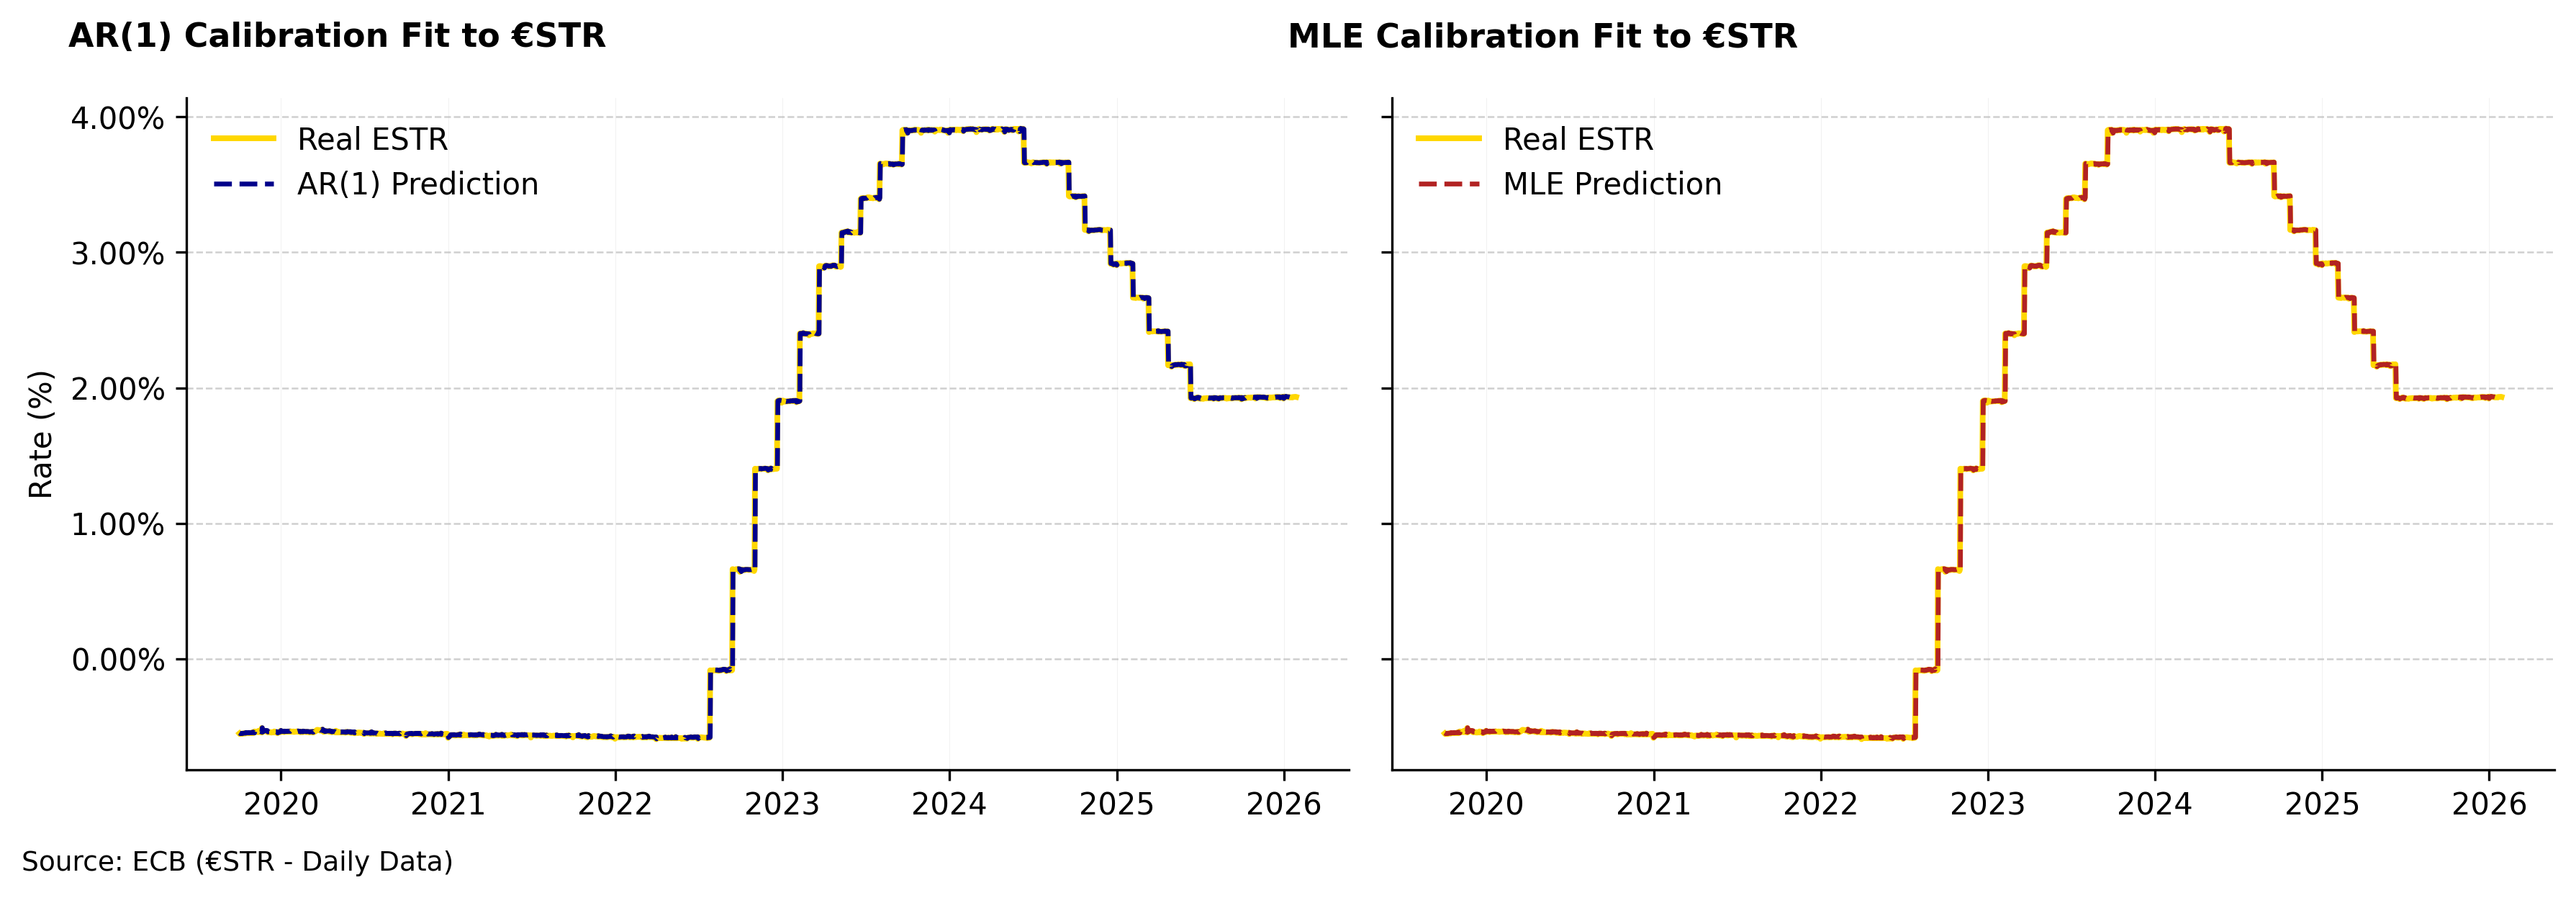

In [9]:
dates = estr["Date"].iloc[1:]

fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=300, sharey=True)

# AR(1) Plot
axes[0].plot(dates, y, linewidth=1.9, color="gold", label="Real ESTR")
axes[0].plot(dates, r_pred, linewidth=1.6, color="darkblue", linestyle="--", label="AR(1) Prediction")
axes[0].set_title("AR(1) Calibration Fit to €STR", fontsize=11, x=0.13, y=1.05, fontweight="bold")
axes[0].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
axes[0].grid(axis="x", linestyle="-", linewidth=0.2, alpha=0.2)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].legend(frameon=False)
axes[0].set_ylabel("Rate (%)")

# MLE Plot
axes[1].plot(dates, r[1:], linewidth=1.9, color="gold", label="Real ESTR")
axes[1].plot(dates, r_pred_mle, linewidth=1.6, color="firebrick", linestyle="--", label="MLE Prediction")
axes[1].set_title("MLE Calibration Fit to €STR", fontsize=11, x=0.13, y=1.05, fontweight="bold")
axes[1].grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
axes[1].grid(axis="x", linestyle="-", linewidth=0.2, alpha=0.2)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].legend(frameon=False)
axes[1].set_ylabel("")

plt.figtext(0.01, -0.02, "Source: ECB (€STR - Daily Data)", fontsize=9, ha="left")
plt.tight_layout()
plt.show()

### **1.2. Term Structure Fitting**

In this section, we calibrate the Nelson-Siegel-Svensson (NSS) model to the current yield curve. Then we derive the instantaneous forward rate $f^M (0,T)$ and determine $\theta(t)$ such that the Hull-White model exactly reproduces the initial term structure.

First, we extract the current yield curve (AAA-rated Bonds - Euro Area, 05/03/2026).

*Source: ECB database*

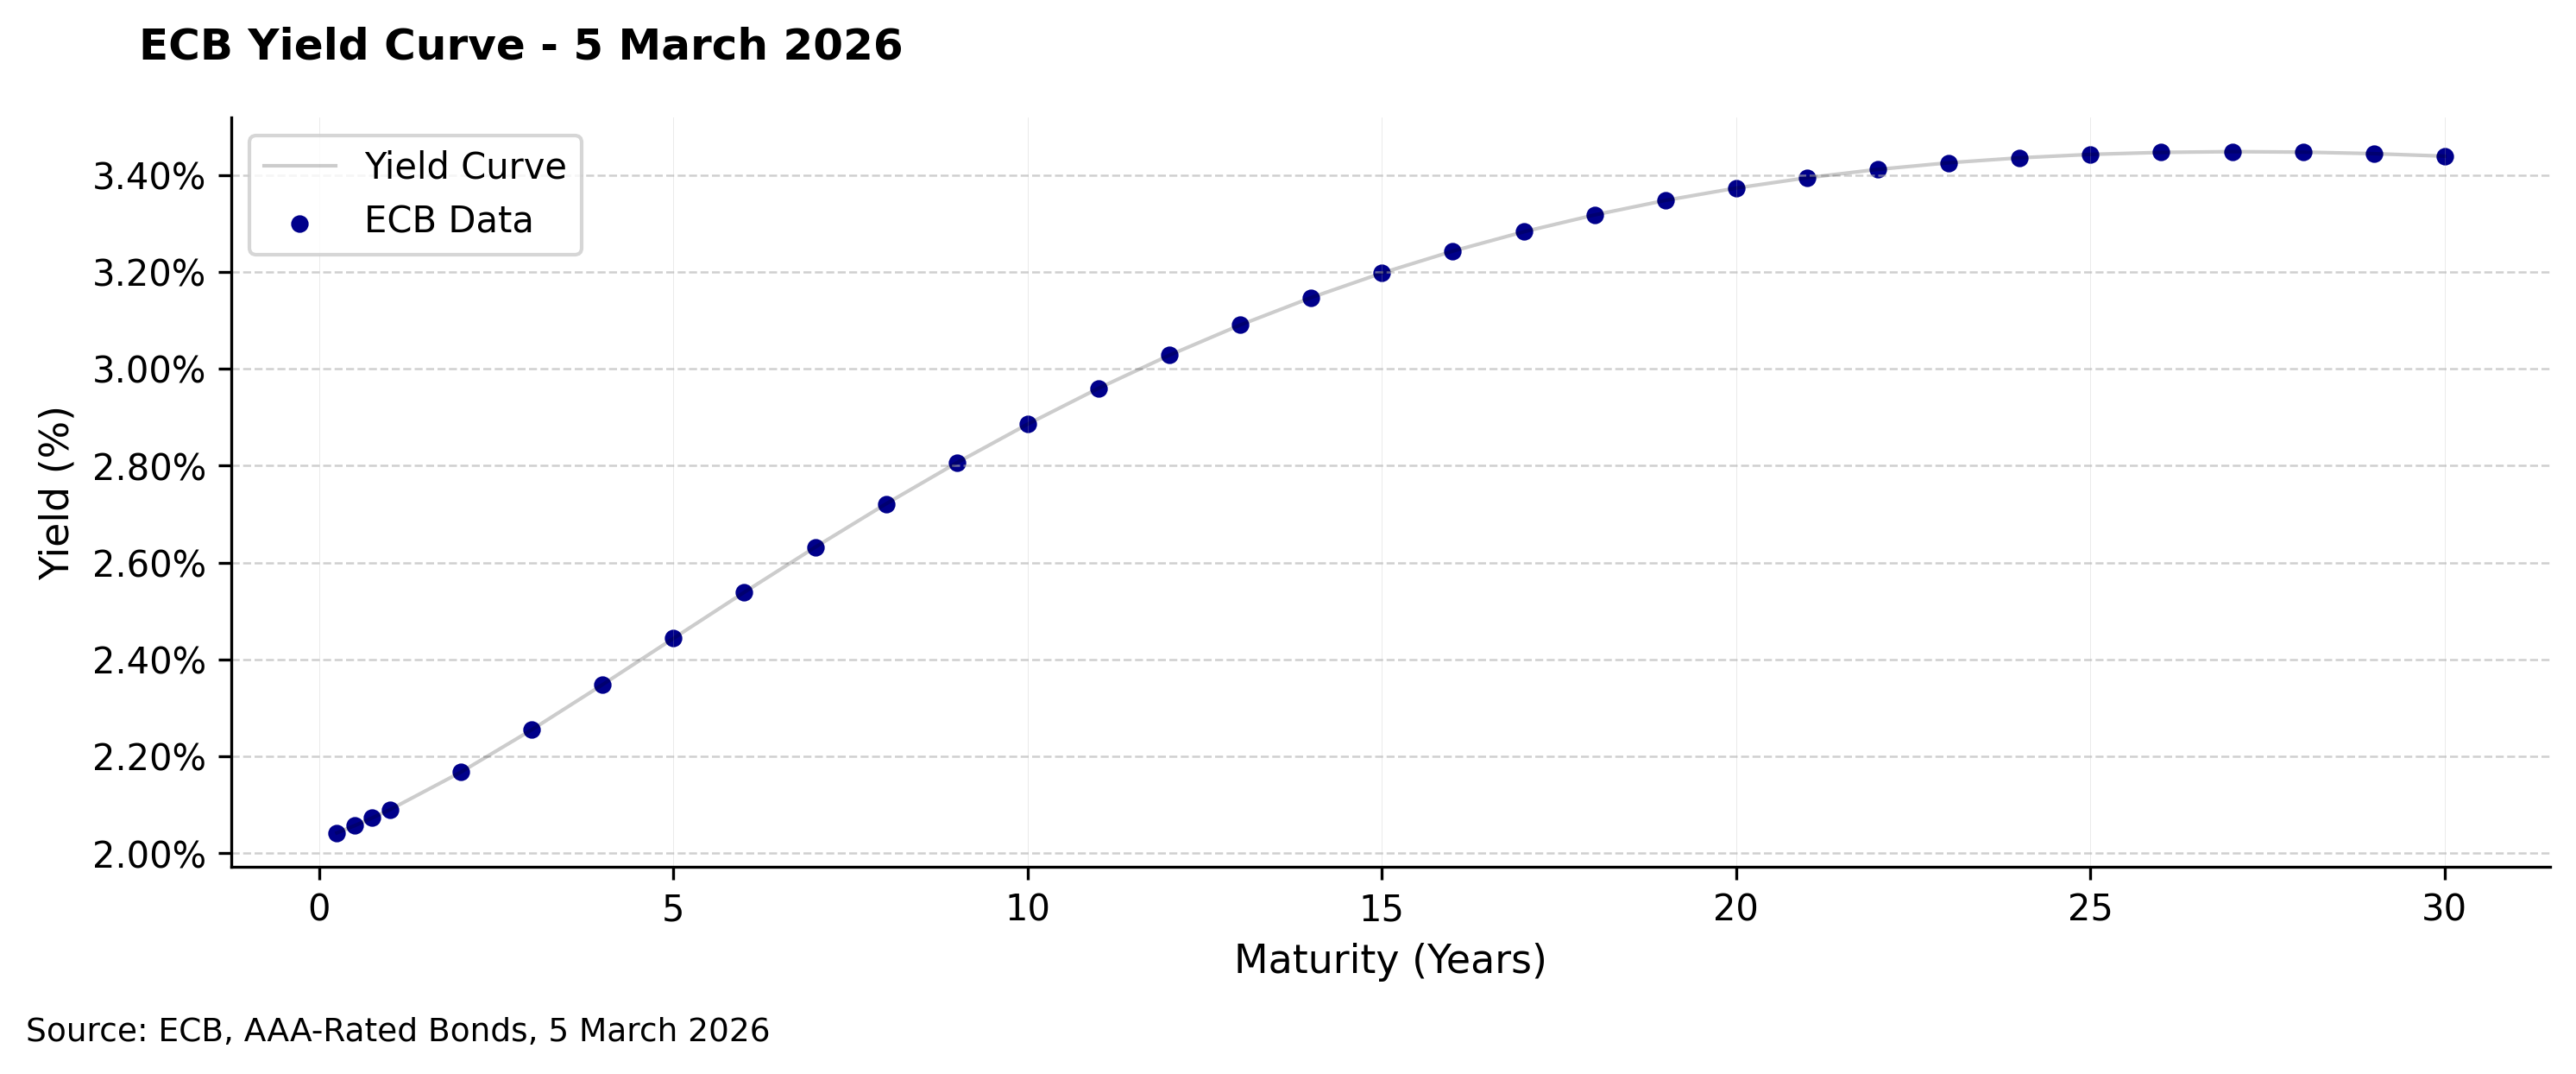

In [10]:
df = pd.DataFrame({
    "maturity": [0.25, 0.5, 0.75, 1] + list(range(2,31)),
    "yield": [2.042299,2.057129,2.073157,2.090272,2.167611,2.255065,2.348202,2.443631,
              2.538790,2.631773,2.721192,2.806070,2.885747,2.959813,3.028050,3.090390,
              3.146871,3.197617,3.242813,3.282683,3.317483,3.347484,3.372967,3.394216,
              3.411515,3.425139,3.435356,3.442425,3.446594,3.448096,3.447154,3.443977,3.438764]
})

df["yield"] = df["yield"] / 100

plt.figure(figsize=(10,4), dpi=300)
plt.plot(df["maturity"], df["yield"], linewidth=1, color="black", alpha=0.2, label="Yield Curve")
plt.scatter(df["maturity"], df["yield"], color="darkblue", marker='o', s=15, label="ECB Data")
plt.legend()


plt.title("ECB Yield Curve - 5 March 2026", fontsize=12, x=0.125, y=1.05, fontweight="bold")
plt.xlabel("Maturity (Years)", fontsize=11)
plt.ylabel("Yield (%)", fontsize=11)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
plt.grid(axis="x", linestyle="-", linewidth=0.2, alpha=0.3)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.figtext(0.01, -0.02, "Source: ECB, AAA-Rated Bonds, 5 March 2026", fontsize=9, ha="left")

plt.tight_layout()
plt.show()

#### **1.2.1. Calibration of Nelson-Siegel-Svensson (NSS) Model to the Current Yield Curve**

The Nelson-Siegel-Svensson (NSS) model is a model for fitting the yield curve. It expresses the zero-coupon yield $y(T)$ for a maturity $T$ as:

$$
y(T) = \beta_0 
+ \beta_1 \frac{1 - e^{-T/\tau_1}}{T/\tau_1} 
+ \beta_2 \left(\frac{1 - e^{-T/\tau_1}}{T/\tau_1} - e^{-T/\tau_1}\right)
+ \beta_3 \left(\frac{1 - e^{-T/\tau_2}}{T/\tau_2} - e^{-T/\tau_2}\right),
$$

where:

- $\beta_0$ : long-term level of the yield curve 
- $\beta_1$ : short-term component (slope)
- $\beta_2$ : medium-term component (curvature)  
- $\beta_3$ : additional medium-to-long term flexibility (curvature)  
- $\tau_1$ : decay factor for the first two components  (years)
- $\tau_2$ : decay factor for the third component  (years)

The NSS model allows for **flexible fitting of the term structure**, capturing the level, slope, and curvature of the yield curve with six parameters.

The model is calibrated to observed yield curve data by providing initial guesses for the six parameters based on economic intuition and curve shape. The bounds are set to ensure stability during the optimization. Using the `curve_fit` function from `scipy.optimize`, the parameters $\beta_0, \beta_1, \beta_2, \beta_3, \tau_1, \tau_2$ are estimated to minimize the difference between the NSS curve and the observed market yields. Once calibrated, these parameters provide a smooth representation of the term structure and can be used to derive instantaneous forward rates and other quantities relevant for interest rate modeling.

In [11]:
def nss(t, beta0, beta1, beta2, beta3, tau1, tau2):
    term1 = beta0
    term2 = beta1 * (1 - np.exp(-t/tau1)) / (t/tau1)
    term3 = beta2 * ((1 - np.exp(-t/tau1)) / (t/tau1) - np.exp(-t/tau1))
    term4 = beta3 * ((1 - np.exp(-t/tau2)) / (t/tau2) - np.exp(-t/tau2))
    return term1 + term2 + term3 + term4

# Initial guesses
p0 = [0.0344, -0.01, 0.01, 0.005, 1.0, 5.0]

# Bounds (for stability)
bounds_lower = [-np.inf, -np.inf, -np.inf, -np.inf, 0.01, 0.01]
bounds_upper = [np.inf, np.inf, np.inf, np.inf, 10, 50]

# Fit
params, cov = curve_fit(nss, df["maturity"], df["yield"], p0=p0, bounds=(bounds_lower, bounds_upper), maxfev=20000)
beta0, beta1, beta2, beta3, tau1, tau2 = params

print("Parameters NSS :")
print("----------------")
print(f"beta0 (%) = {beta0*100:.6f}")
print(f"beta1 (%) = {beta1*100:.6f}")
print(f"beta2 (%) = {beta2*100:.6f}")
print(f"beta3 (%) = {beta3*100:.6f}")
print(f"tau1  = {tau1:.6f}")
print(f"tau2  = {tau2:.6f}")

Parameters NSS :
----------------
beta0 (%) = 1.230620
beta1 (%) = 0.798165
beta2 (%) = -1.171481
beta3 (%) = 7.637704
tau1  = 4.750481
tau2  = 14.769140


It is exactly the parameters we can find on the ECB website for March 5 2026.

| Parameter | Value |
|-----------|-------|
| $\beta_0$ | 1.230734 |
| $\beta_1$ | 0.798051 |
| $\beta_2$| -1.171657 |
| $\beta_3$ | 7.637499 |
| $\tau_1$| 4.750658 |
| $\tau_2$| 14.768778 |

*Source: ECB Parameters NSS Model 05/03/2026*

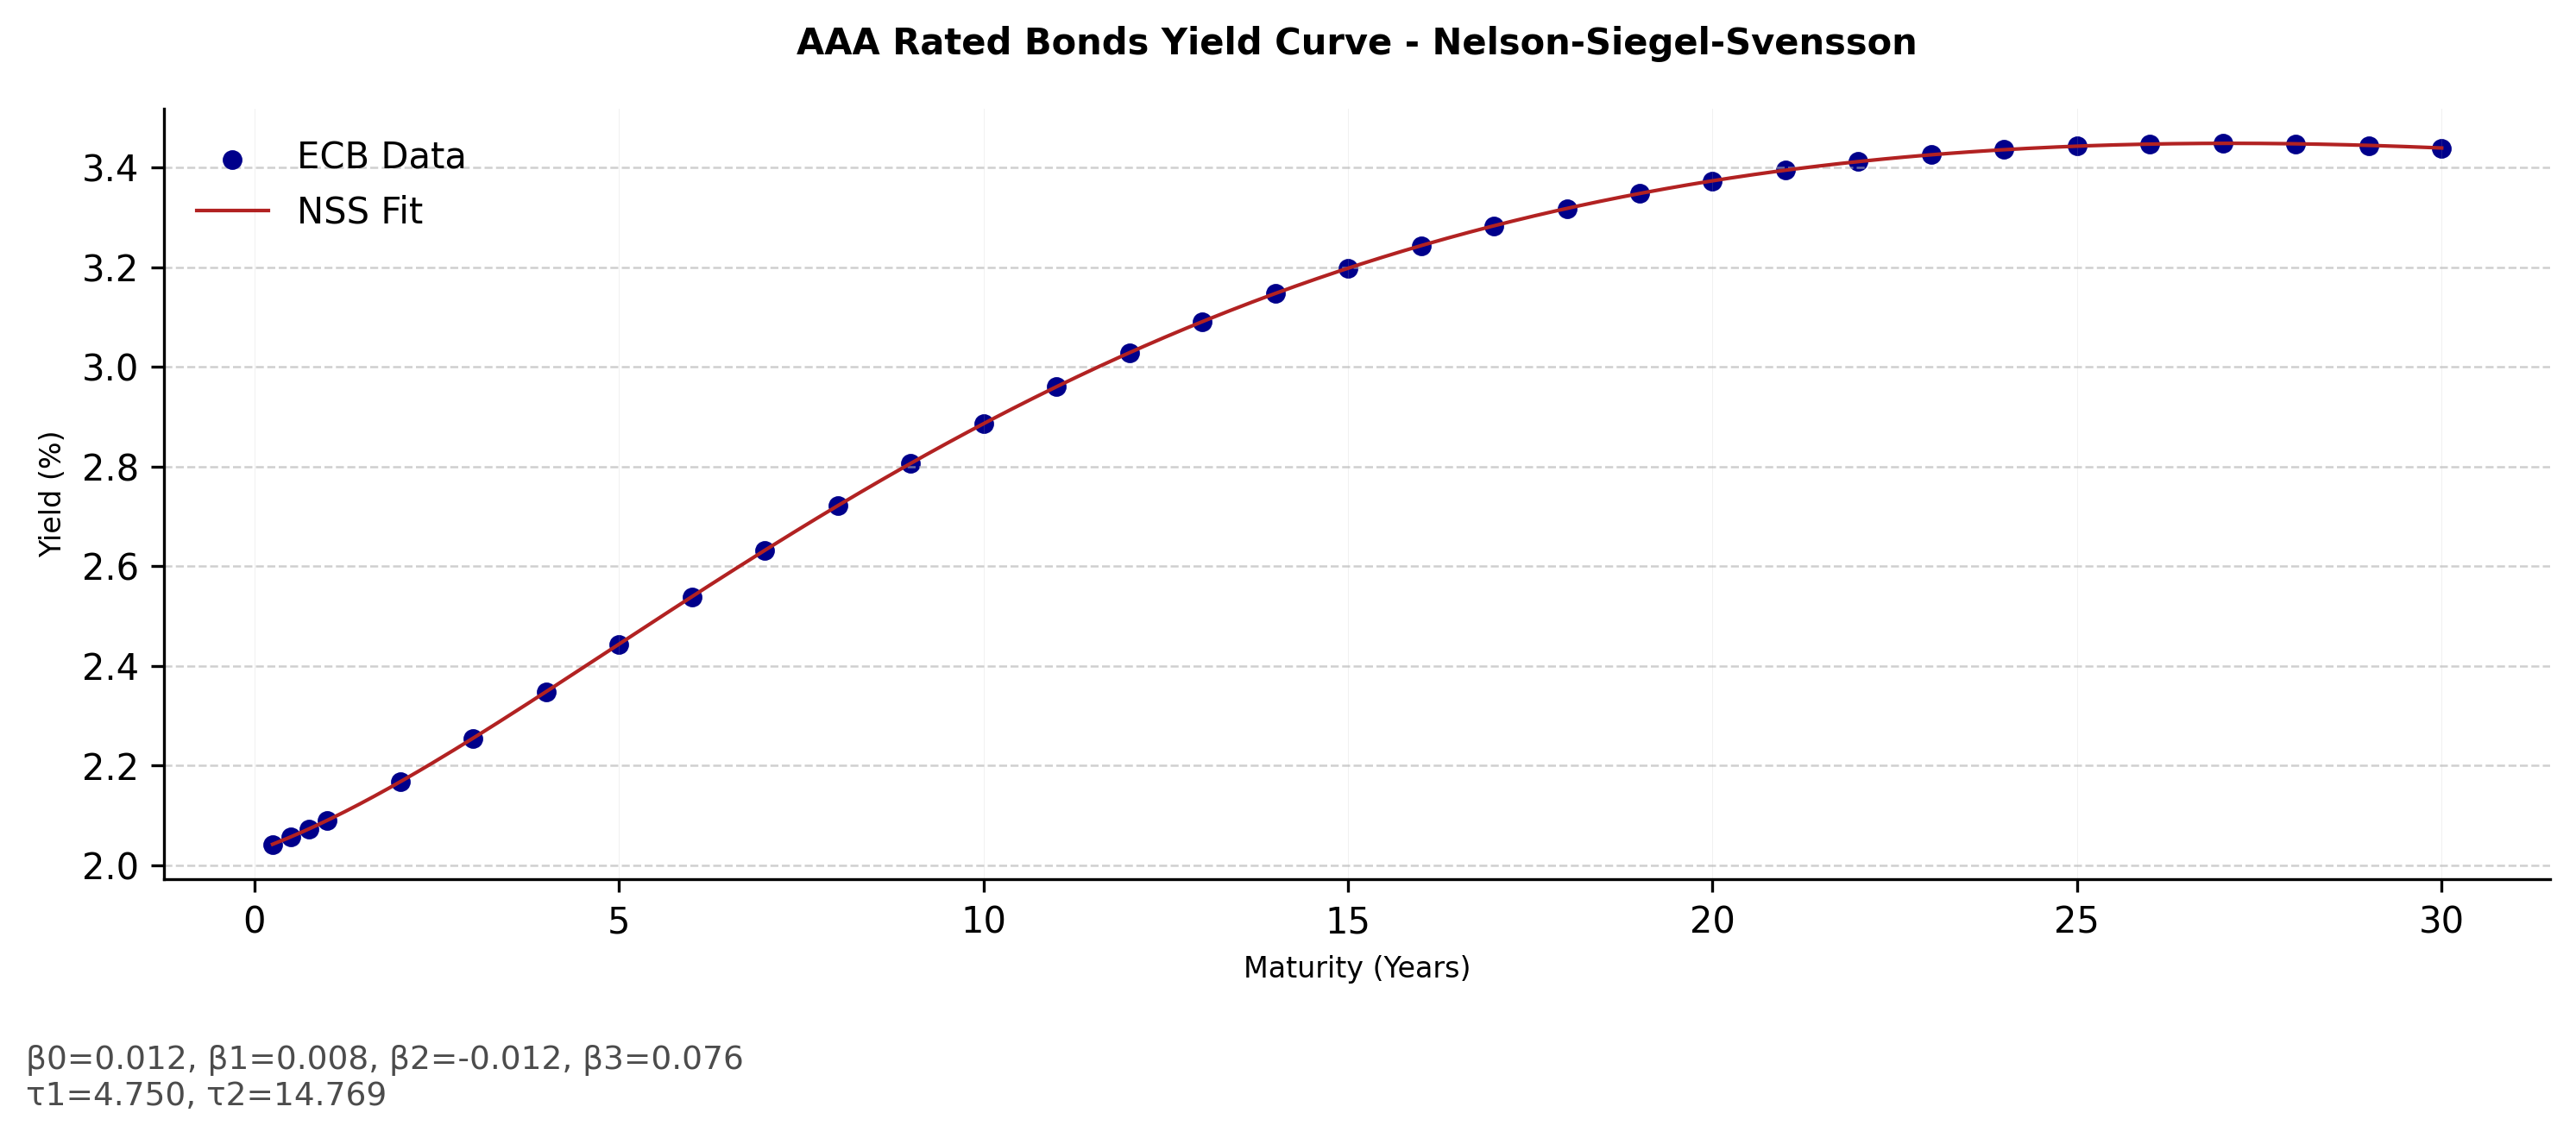

In [12]:
plt.figure(figsize=(10,4), dpi=300)

t_fit = np.linspace(0.25, 30, 300)
plt.scatter(df["maturity"], df["yield"]*100, color='darkblue', s=20, label='ECB Data')
plt.plot(t_fit, nss(t_fit, *params)*100, color="firebrick", lw=1, label='NSS Fit')


plt.xlabel("Maturity (Years)", fontsize=8)
plt.ylabel("Yield (%)", fontsize=8)
plt.title("AAA Rated Bonds Yield Curve - Nelson-Siegel-Svensson", fontsize=10, fontweight='bold', pad=15)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
plt.grid(axis="x", linestyle="-", linewidth=0.2, alpha=0.2)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False, fontsize=10)

param_text = f"β0={beta0:.3f}, β1={beta1:.3f}, β2={beta2:.3f}, β3={beta3:.3f}\nτ1={tau1:.3f}, τ2={tau2:.3f}"
plt.figtext(0.01, -0.08, param_text, fontsize=9, alpha=0.7, ha="left")  # texte sous le plot

plt.tight_layout()
plt.show()

### **1.2.2 Instantaneous Forward Rate and Time-dependent Reversion Level**

From the calibrated Nelson–Siegel–Svensson (NSS) yield curve $y(T)$, the **instantaneous forward rate** $f^M(0,T)$ is computed as:

$$
f^M(0,T) = y(T) + T \frac{\partial y(T)}{\partial T}.
$$

For the NSS model:

$$
y(T) = \beta_0 + \beta_1 \frac{1 - e^{-T/\tau_1}}{T/\tau_1} 
+ \beta_2 \left(\frac{1 - e^{-T/\tau_1}}{T/\tau_1} - e^{-T/\tau_1}\right)
+ \beta_3 \left(\frac{1 - e^{-T/\tau_2}}{T/\tau_2} - e^{-T/\tau_2}\right),
$$

its derivative with respect to $T$ is analytical:

$$
\frac{\partial}{\partial T} \left[\frac{1 - e^{-T/\tau}}{T/\tau}\right] 
= \frac{e^{-T/\tau}}{T} - \frac{1 - e^{-T/\tau}}{T^2}.
$$

Using this, we can compute the forward rate $f^M(0,T)$ for any maturity $T$.


**Proof : Instantaneous Forward Rate**

To derive the relationship between the instantaneous forward rate $f^M(0,T)$ and the zero-coupon yield $y(T)$, we start with the fundamental pricing equation for a zero-coupon bond. 

The price of a zero-coupon bond $P(0,T)$ maturing at time $T$, given a continuously compounded yield $y(T)$, is defined as:
$$P(0,T) = e^{-y(T)T}$$

The instantaneous forward rate $f^M(0,T)$ is defined theoretically as the negative derivative of the log bond price with respect to maturity $T$:
$$f^M(0,T) = -\frac{\partial \ln P(0,T)}{\partial T}$$

First, we take the natural logarithm of the bond price equation:
$$\ln P(0,T) = -y(T)T$$

Next, we differentiate this expression with respect to $T$ using the product rule. The derivative of $-y(T)T$ requires differentiating both the yield function and the time variable:
$$\frac{\partial \ln P(0,T)}{\partial T} = -\left( y(T) \cdot \frac{\partial T}{\partial T} + T \cdot \frac{\partial y(T)}{\partial T} \right)$$

This simplifies to:
$$\frac{\partial \ln P(0,T)}{\partial T} = -\left( y(T) + T \frac{\partial y(T)}{\partial T} \right)$$

Finally, substituting this derivative back into the definition of the instantaneous forward rate perfectly cancels the negative signs:
$$f^M(0,T) = -\left[ -\left( y(T) + T \frac{\partial y(T)}{\partial T} \right) \right]$$

Which yields the final exact formula:
$$f^M(0,T) = y(T) + T \frac{\partial y(T)}{\partial T}$$



In [13]:
T = np.array(df['maturity'])

def get_nss_rates(T, b0, b1, b2, b3, t1, t2):
    # Small epsilon to avoid division by zero at T=0
    T_safe = np.where(T == 0, 1e-10, T)
    
    # ZC Yield Function y(T)
    term1 = (1 - np.exp(-T_safe/t1)) / (T_safe/t1)
    term2 = term1 - np.exp(-T_safe/t1)
    term3 = ((1 - np.exp(-T_safe/t2)) / (T_safe/t2)) - np.exp(-T_safe/t2)
    
    y_T = b0 + (b1 * term1) + (b2 * term2) + (b3 * term3)
    
    # Instantaneous Forward Rate Function f(0,T)
    f_T = (b0 + 
           b1 * np.exp(-T_safe/t1) + 
           b2 * (T_safe/t1) * np.exp(-T_safe/t1) + 
           b3 * (T_safe/t2) * np.exp(-T_safe/t2))
    
    return y_T, f_T


yields, forwards = get_nss_rates(T, beta0, beta1, beta2, beta3, tau1, tau2)

df_fwd = pd.DataFrame({
    "Maturity (Years)": T,
    "Spot Yield": yields,
    "Forward Rate": forwards
})

df_fwd.round(4)
df_fwd.head()

,Maturity (Years),Spot Yield,Forward Rate
0,0.25,0.020423,0.020565
1,0.50,0.020571,0.020880
2,0.75,0.020732,0.021229
3,1.00,0.020903,0.021608
4,2.00,0.021676,0.023341


The **Hull–White one-factor model** is defined as:

$$
dr_t = (\theta(t) - a\, r_t)\, dt + \sigma\, dW_t,
$$

where $a$ is the mean-reversion parameter and $\sigma$ is the volatility.

To exactly reproduce the initial term structure, the **time-dependent reversion level** $\theta(t)$ is given by:

$$
\theta(t) = \frac{\partial f^M(0,t)}{\partial t} + a\, f^M(0,t) + \frac{\sigma^2}{2a} \left(1 - e^{-2 a t}\right),
$$

where $f^M(0,t)$ is the instantaneous forward rate derived from the NSS curve.

**Proof : Mean-reversion level in the HW model**

To derive the time-dependent reversion level $\theta(t)$ in the Hull-White one-factor model, we start by integrating the short rate stochastic differential equation $dr_t = (\theta(t) - a r_t)dt + \sigma dW_t$. The solution evaluated from $0$ to $t$ gives the short rate:

$$r_t = r_0 e^{-at} + \int_0^t e^{-a(t-u)} \theta(u) du + \int_0^t \sigma e^{-a(t-u)} dW_u$$

By taking the expected value under the risk-neutral measure, the stochastic integral drops out because it is a martingale with an expectation of zero. This leaves us with the expected future short rate:

$$\mathbb{E}[r_t] = r_0 e^{-at} + \int_0^t e^{-a(t-u)} \theta(u) du$$

The initial instantaneous forward rate $f^M(0,t)$ observed in the market is related to the expected future short rate by subtracting a deterministic convexity adjustment caused by the volatility:

$$f^M(0,t) = \mathbb{E}[r_t] - \frac{\sigma^2}{2a^2}(1 - e^{-at})^2$$

Substituting our expanded expectation into this formula gives the relationship between the market forward curve and $\theta(t)$:

$$f^M(0,t) = r_0 e^{-at} + \int_0^t e^{-a(t-u)} \theta(u) du - \frac{\sigma^2}{2a^2}(1 - e^{-at})^2$$

To isolate $\theta(t)$, we must differentiate both sides with respect to $t$. Using the Leibniz integral rule on the integral term yields $\theta(t) - a \int_0^t e^{-a(t-u)} \theta(u) du$. The full differentiation is:

$$\frac{\partial f^M(0,t)}{\partial t} = -a r_0 e^{-at} + \theta(t) - a \int_0^t e^{-a(t-u)} \theta(u) du - \frac{\sigma^2}{a} e^{-at} (1 - e^{-at})$$

We can factor out $-a$ from the first and third terms to reconstruct the expected value expression:

$$\frac{\partial f^M(0,t)}{\partial t} = \theta(t) - a \left( r_0 e^{-at} + \int_0^t e^{-a(t-u)} \theta(u) du \right) - \frac{\sigma^2}{a} (e^{-at} - e^{-2at})$$

Notice that the term in the large parentheses is exactly $\mathbb{E}[r_t]$. We can express $\mathbb{E}[r_t]$ using our earlier forward rate equation as $\mathbb{E}[r_t] = f^M(0,t) + \frac{\sigma^2}{2a^2}(1 - e^{-at})^2$. Substituting this back into the derivative gives:

$$\frac{\partial f^M(0,t)}{\partial t} = \theta(t) - a \left( f^M(0,t) + \frac{\sigma^2}{2a^2}(1 - e^{-at})^2 \right) - \frac{\sigma^2}{a} (e^{-at} - e^{-2at})$$

Rearranging the equation to solve for $\theta(t)$ moves all other components to the left side:

$$\theta(t) = \frac{\partial f^M(0,t)}{\partial t} + a f^M(0,t) + \frac{\sigma^2}{2a} (1 - e^{-at})^2 + \frac{\sigma^2}{a} (e^{-at} - e^{-2at})$$

Expanding the squared term $(1 - e^{-at})^2 = 1 - 2e^{-at} + e^{-2at}$ allows us to combine the two volatility components over a common denominator:

$$\theta(t) = \frac{\partial f^M(0,t)}{\partial t} + a f^M(0,t) + \frac{\sigma^2}{2a} \left( 1 - 2e^{-at} + e^{-2at} + 2e^{-at} - 2e^{-2at} \right)$$

Simplifying the terms inside the parentheses perfectly cancels out the $2e^{-at}$ components and reduces the squared exponential. This leads directly to the final exact formula used to perfectly calibrate the Hull-White model to the initial term structure:

$$\theta(t) = \frac{\partial f^M(0,t)}{\partial t} + a f^M(0,t) + \frac{\sigma^2}{2a} (1 - e^{-2at})$$

In [14]:
T = df["maturity"].values

def calculate_hull_white_theta(T, a, sigma, beta0, beta1, beta2, beta3, tau1, tau2):
    f_T = (beta0 + 
           beta1 * np.exp(-T/tau1) + 
           beta2 * (T/tau1) * np.exp(-T/tau1) + 
           beta3 * (T/tau2) * np.exp(-T/tau2))

    df_dT = (
        -(beta1 / tau1) * np.exp(-T/tau1) +
        (beta2 / tau1) * np.exp(-T/tau1) * (1 - T/tau1) +
        (beta3 / tau2) * np.exp(-T/tau2) * (1 - T/tau2)
    )

    theta_t = df_dT + a * f_T + (sigma**2 / (2 * a)) * (1 - np.exp(-2 * a * T))
    
    return theta_t, f_T, df_dT


theta, fwd, slope = calculate_hull_white_theta(T, a_hat, sigma_hat, beta0, beta1, beta2, beta3, tau1, tau2)

df_results = pd.DataFrame({
    "Maturity (y)": T,
    "Forward Rate": fwd,
    "df/dT": slope,
    "Theta(t)": theta
})

df_results.round(6)
df_results.head()

,Maturity (y),Forward Rate,df/dT,Theta(t)
0,0.25,0.020565,0.001188,0.003916
1,0.50,0.020880,0.001332,0.004111
2,0.75,0.021229,0.001458,0.004292
3,1.00,0.021608,0.001567,0.004461
4,2.00,0.023341,0.001865,0.005017


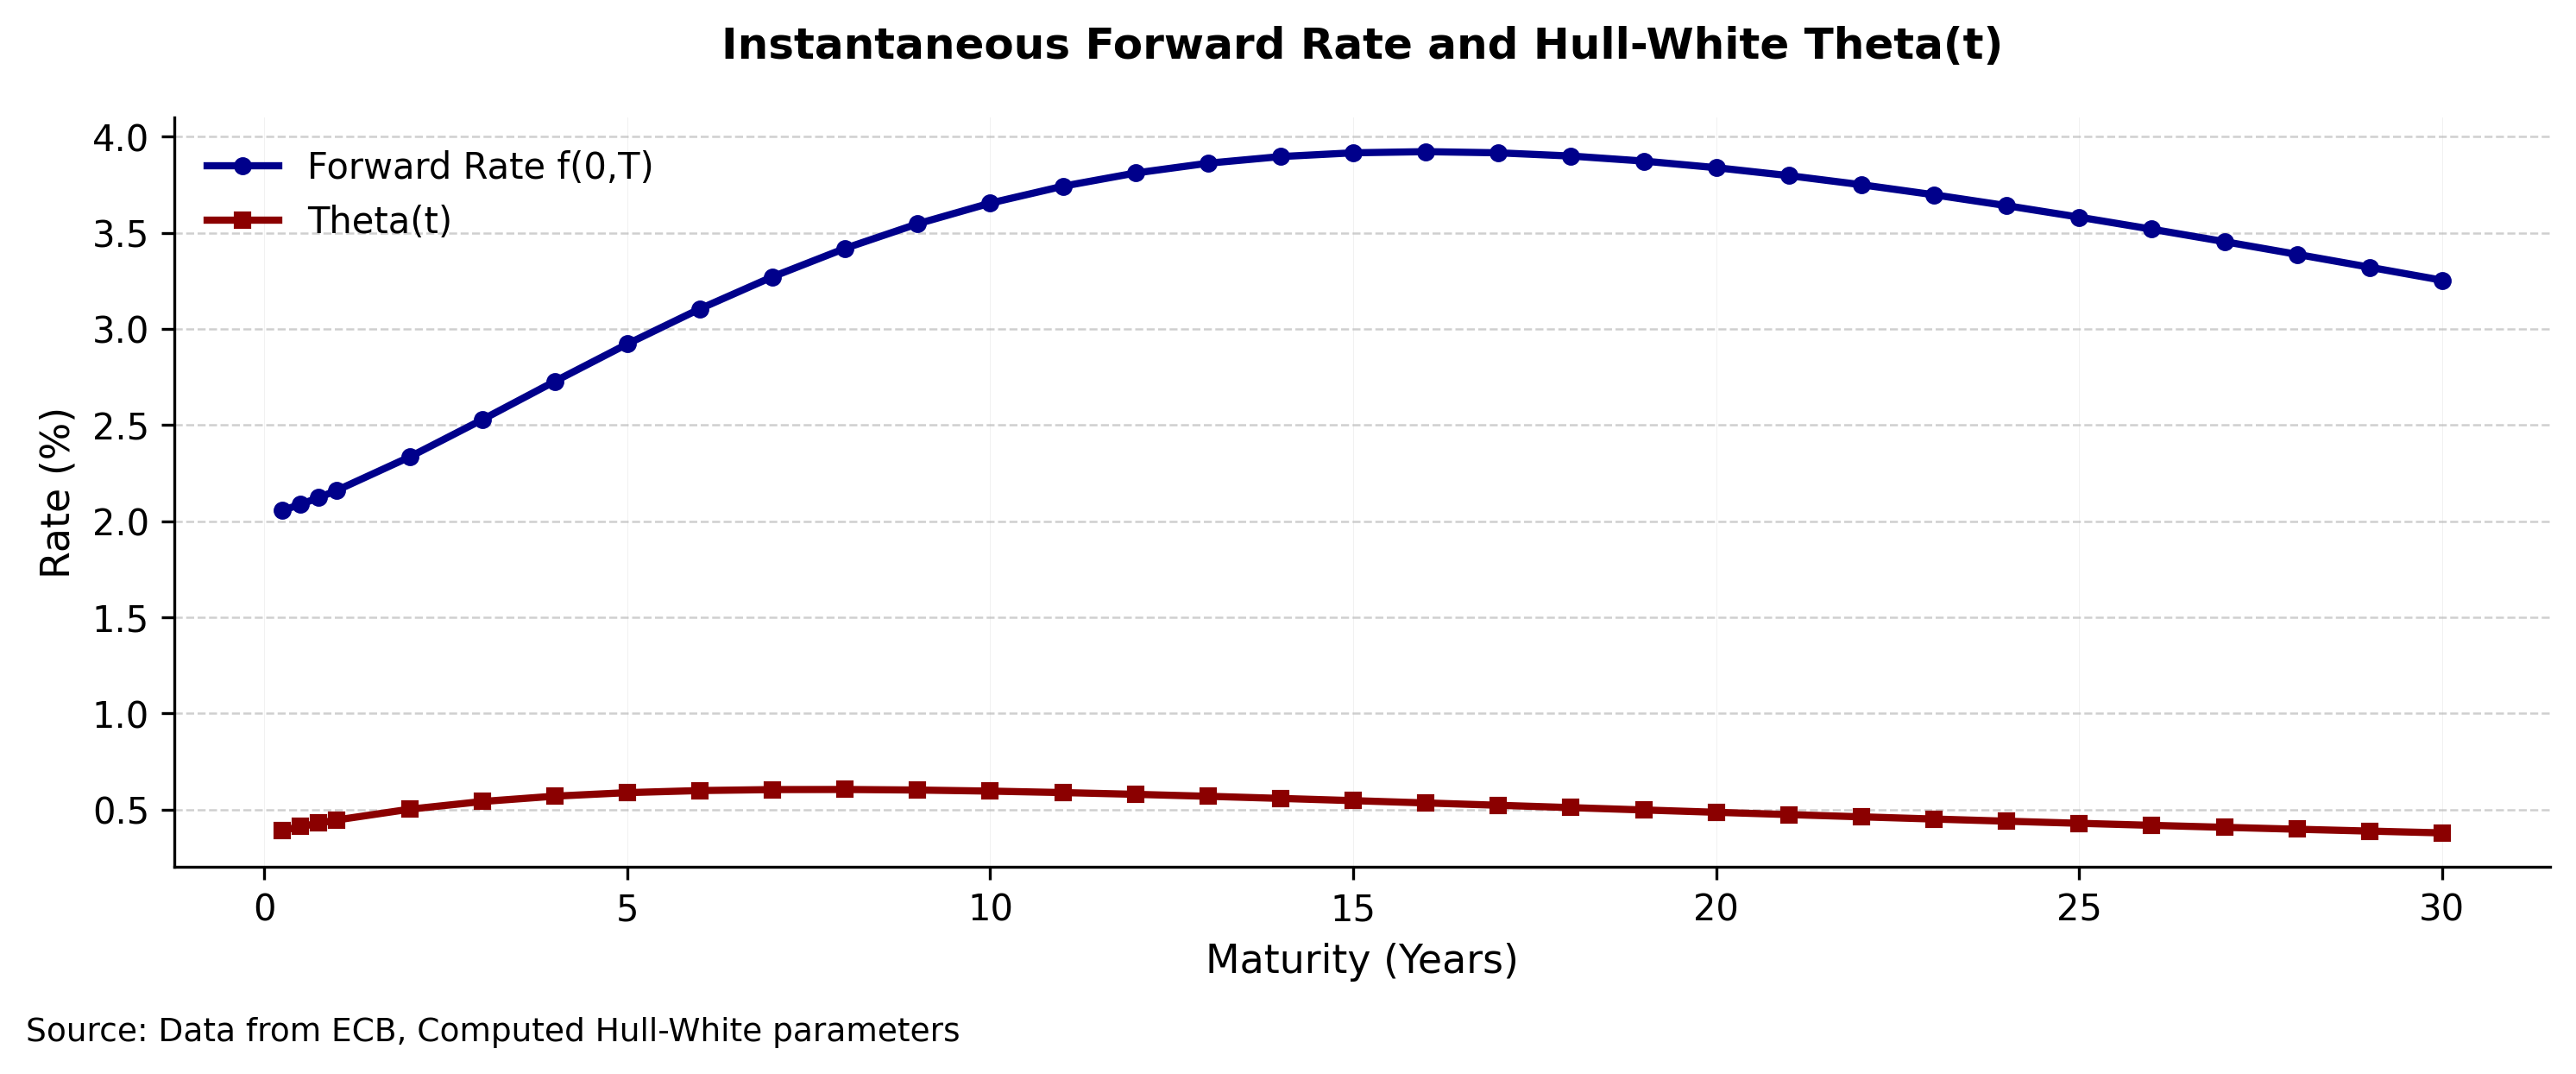

In [15]:
plt.figure(figsize=(10,4), dpi=300)

plt.plot(df_results["Maturity (y)"], df_results["Forward Rate"]*100, 
         linewidth=2, color="darkblue", marker='o', markersize=4, label="Forward Rate f(0,T)")
plt.plot(df_results["Maturity (y)"], df_results["Theta(t)"]*100, 
         linewidth=2, color="darkred", linestyle="-", marker='s', markersize=4, label="Theta(t)")

plt.title("Instantaneous Forward Rate and Hull-White Theta(t)", fontsize=12, x=0.5, y=1.05, fontweight="bold")
plt.xlabel("Maturity (Years)", fontsize=11)
plt.ylabel("Rate (%)", fontsize=11)

plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
plt.grid(axis="x", linestyle="-", linewidth=0.2, alpha=0.2)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False, fontsize=10)
plt.figtext(0.01, -0.02, "Source: Data from ECB, Computed Hull-White parameters", fontsize=9, ha="left")

plt.tight_layout()
plt.show()

The instantaneous forward rate curve $f(0,T)$ exhibits a distinct hump-backed structure, rising from an initial level of approximately 2.0% to a peak near 3.9% around the 15-year maturity mark before gradually declining towards 3.25% at the 30-year horizon. In contrast, the time-dependent reversion level $\theta(t)$ operates at a significantly lower magnitude, peaking early at approximately 0.35% and steadily decreasing towards 0.1%. 

This relationship is a direct mathematical consequence of the Hull-White calibration mechanics. In the short-to-medium term, $\theta(t)$ remains elevated to systematically pull the simulated short rates upward to match the steeply rising forward curve. However, as the forward curve loses momentum and its slope $\frac{\partial f(0,t)}{\partial t}$ becomes negative past year 15, the combined effect of this negative derivative and the progressively accumulating convexity adjustment forces $\theta(t)$ to decline smoothly, ensuring the simulated rates do not overshoot the long end of the market term structure.

## **2. Multi-Measure Monte-Carlo Pricing**

In this section, we value a European payer swaption (10-year underlying swap, annual payments, **2%** strike, maturity $T=2$ years) with Monte-Carlo simulations under three distinct probability measures.

A European payer swaption grants the holder the right, but not the obligation, to enter into an interest rate swap as the fixed-rate payer at a specific expiration date. Given our contract specifications, at maturity $T=2$ years, the holder has the right to enter a 10-year swap where they will pay a fixed annual rate of 2% and receive the floating reference rate. The holder will logically only exercise this option if the prevailing 10-year market swap rate at year 2 is strictly greater than the 2% strike rate. 

We will price this instrument using the following approaches:

* **Risk-Neutral Measure ($\mathbb{Q}$):** We use the bank account $B_t$ as the numeraire.

* **Forward Measure ($\mathbb{Q}^T$):** We use the zero-coupon bond maturing at the swaption exercise date $T$ as the numeraire. We will derive the corresponding drift adjustment for $r_t$ under this measure.

* **Annuity Measure ($\mathbb{Q}^A$):** We use the swap annuity as the numeraire. 

$$A_{n,m}(t) = \sum_{i=n+1}^{m} \tau_i P(t, T_i)$$

Then we derive the drift correction required to make the forward swap rate a martingale under this measure. Finally, we identify which numeraire produces the lowest Monte Carlo variance of the pricing estimator.


#### Monte Carlo Swaption Pricing (Hull–White Model) - General Idea

1. **Define the swaption** – specify option maturity, swap tenor, strike rate, and notional.  
   
2. **Set up Hull–White model** – choose parameters $a, \sigma, \theta(t)$ calibrated to the yield curve and market volatilities.  
   
3. **Simulate short rate paths** – generate multiple realizations of $r(t)$ using exact or discretized Hull–White dynamics.  
   
4. **Compute payoffs** – evaluate the swap value at option expiry and apply $\max(V_{\text{swap}},0)$ for payer (or $\max(-V_{\text{swap}},0)$ for receiver).
     
5. **Average and discount** – discount each path’s payoff using simulated short rates, then average across paths to get the Monte Carlo price.


### **2.1. Risk-Neutral Measure Pricing**

Under the Risk-Neutral Measure ($\mathbb{Q}$), the numeraire is the continuously compounded bank account, which is defined as:

$$B_t = \exp\left(\int_0^t r_s ds\right)$$

To value the swaption, we first define the payoff of the underlying swap at the exercise date. Let $T = 2$ be the swaption maturity. The underlying swap has a 10-year tenor with annual payments, meaning the payment dates are $T_i = T + i$ for $i = 1, \dots, 10$ (corresponding to years 3 through 12). Since payments are annual, the day-count fractions are $\tau_i = 1$.

At maturity $T$, the value of the underlying payer swap to the fixed-rate payer is the difference between the floating leg and the fixed leg. In terms of zero-coupon bonds $P(T, T_i)$, this is:

$$V_{\text{swap}}(T) = 1 - P(T, T_{10}) - K \sum_{i=1}^{10} P(T, T_i)$$

where $K = 0.02$ is the fixed strike rate. 

The payoff of the European payer swaption at $T$ is the positive part of the underlying swap's value:

$$H(T) = \max(V_{\text{swap}}(T), 0) = \left( 1 - P(T, T_{10}) - 0.02 \sum_{i=1}^{10} P(T, T_i) \right)^+$$

According to the fundamental theorem of asset pricing, the price of any tradable asset discounted by the numeraire is a martingale under the measure associated with that numeraire. Therefore, the value of the swaption today ($t=0$) is the expected value of the discounted payoff under the risk-neutral measure $\mathbb{Q}$:

$$V(0) = B_0 \mathbb{E}^{\mathbb{Q}} \left[ \frac{H(T)}{B_T} \right]$$

Since the bank account starts at $B_0 = 1$ and grows at the short rate, $B_T = \exp(\int_0^T r_s ds)$, this equation tells us that the price today is the expected value of the payoff, discounted along the simulated short rate paths. We substitute our bank account and payoff formulas into the expectation:

$$V(0) = \mathbb{E}^{\mathbb{Q}} \left[ e^{-\int_0^2 r_s ds} \left( 1 - P(2, 12) - 0.02 \sum_{i=1}^{10} P(2, 2+i) \right)^+ \right]$$


**Remark:** The formula below is a direct application of the **Fundamental Theorem of Asset Pricing**. 

$$V(0) = B_0 \mathbb{E}^{\mathbb{Q}} \left[ \frac{H(T)}{B_T} \right]$$ 

In arbitrage-free pricing theory, if we choose a strictly positive tradable asset as our numeraire (in this case, the money market bank account $B_t$), there exists an equivalent martingale measure (the risk-neutral measure $\mathbb{Q}$) associated with it. 

Under this measure $\mathbb{Q}$, the price of any tradable asset $V(t)$ relative to the numeraire $B_t$ must be a martingale. The martingale property implies that the best estimate of the future discounted price is simply the current discounted price:

$$\frac{V(t)}{B_t} = \mathbb{E}^{\mathbb{Q}} \left[ \frac{V(T)}{B_T} \Big| \mathcal{F}_t \right]$$

where $\mathcal{F}_t$ represents the information available at time $t$. 

If we evaluate this at today's date ($t=0$), the conditioning on $\mathcal{F}_0$ drops out because the present state is known. Furthermore, at maturity $T$, the value of the derivative $V(T)$ is exactly equal to its payoff function $H(T)$. Substituting these gives:

$$\frac{V(0)}{B_0} = \mathbb{E}^{\mathbb{Q}} \left[ \frac{H(T)}{B_T} \right]\textit{ i.e. } V(0) = B_0 \mathbb{E}^{\mathbb{Q}} \left[ \frac{H(T)}{B_T} \right] $$ 


**Initial Term Structure and Time-Dependent Mean-reversion Level**

The below section defines the functions that will be used across **all three pricing methods** (Risk-Neutral $\mathbb{Q}$, Forward $\mathbb{Q}^T$, and Annuity $\mathbb{Q}^A$). 

Regardless of the probability measure chosen to simulate the paths of the short rate $r_t$, the initial yield curve calibration and the relationship between the short rate and zero-coupon bond prices remain the same. 

* `y_nss`: Calculates the continuously compounded zero-coupon yield $y(T)$.
* `P_0`: Calculates the initial discount factor / zero-coupon bond price $P(0, T)$.
* `f_0`: Calculates the initial instantaneous forward rate $f(0, T)$.


In the Hull-White model, the price of a zero-coupon bond at time $t$ is an affine function of the short rate $r_t$, expressed as $P(t, T) = A(t, T) e^{-B(t, T) r_t}$.
* `hw_A` and `hw_B`: Compute the deterministic components $A(t, T)$ and $B(t, T)$ based on the mean reversion $a$, volatility $\sigma$, and the initial forward curve.
* `hw_ZCB`: Returns the simulated price of a zero-coupon bond $P(t, T)$ given a simulated short rate $r_t$.
* `theta`: Calculates the deterministic drift parameter $\theta(t)$ required to perfectly calibrate the Hull-White model to the initial NSS forward curve.

In [16]:
def y_nss(T, b0, b1, b2, b3, t1, t2):
    T_safe = np.where(T == 0, 1e-10, T)
    t1_term = (1 - np.exp(-T_safe / t1)) / (T_safe / t1)
    t2_term = (1 - np.exp(-T_safe / t2)) / (T_safe / t2)
    return b0 + b1 * t1_term + b2 * (t1_term - np.exp(-T_safe / t1)) + b3 * (t2_term - np.exp(-T_safe / t2))

def P_0(T, b0, b1, b2, b3, t1, t2):
    return np.exp(-y_nss(T, b0, b1, b2, b3, t1, t2) * T)

def f_0(T, b0, b1, b2, b3, t1, t2):
    T_safe = np.where(T == 0, 1e-10, T)
    return b0 + b1 * np.exp(-T_safe / t1) + b2 * (T_safe / t1) * np.exp(-T_safe / t1) + b3 * (T_safe / t2) * np.exp(-T_safe / t2)

def hw_A(t, T, a, sigma, b0, b1, b2, b3, t1, t2):
    B_t_T = (1 - np.exp(-a * (T - t))) / a
    P_0_T = P_0(T, b0, b1, b2, b3, t1, t2)
    P_0_t = P_0(t, b0, b1, b2, b3, t1, t2)
    f_0_t = f_0(t, b0, b1, b2, b3, t1, t2)
    exponent = B_t_T * f_0_t - (sigma**2 / (4 * a)) * (1 - np.exp(-2 * a * t)) * (B_t_T**2)
    return (P_0_T / P_0_t) * np.exp(exponent)

def hw_B(t, T, a):
    return (1 - np.exp(-a * (T - t))) / a

def hw_ZCB(t, T, r_t, a, sigma, b0, b1, b2, b3, t1, t2):
    A = hw_A(t, T, a, sigma, b0, b1, b2, b3, t1, t2)
    B = hw_B(t, T, a)
    return A * np.exp(-B * r_t)

def theta(t, a, sigma, b0, b1, b2, b3, t1, t2):
    T_safe = np.where(t == 0, 1e-10, t)
    df_dT = (-(b1 / t1) * np.exp(-T_safe / t1) + 
             (b2 / t1) * np.exp(-T_safe / t1) * (1 - T_safe / t1) + 
             (b3 / t2) * np.exp(-T_safe / t2) * (1 - T_safe / t2))
    return df_dT + a * f_0(t, b0, b1, b2, b3, t1, t2) + (sigma**2 / (2 * a)) * (1 - np.exp(-2 * a * t))

In [17]:
def simulate_paths(M, N, T, a, sigma, b0, b1, b2, b3, t1, t2):
    dt = T / N
    r = np.zeros((N + 1, M))
    r[0] = f_0(0, b0, b1, b2, b3, t1, t2)
    
    for i in range(N):
        t = i * dt
        th = theta(t, a, sigma, b0, b1, b2, b3, t1, t2)
        Z = np.random.standard_normal(M)
        r[i+1] = r[i] + (th - a * r[i]) * dt + sigma * np.sqrt(dt) * Z
        
    discount_factors = np.exp(-np.sum(r[:-1], axis=0) * dt)
    return r[-1], discount_factors

def price_swaption(M, N, T, tenor, K, a, sigma, b0, b1, b2, b3, t1, t2):
    r_T, discount_factors = simulate_paths(M, N, T, a, sigma, b0, b1, b2, b3, t1, t2)
    
    payment_dates = T + np.arange(1, tenor + 1)
    sum_P = np.zeros(M)
    
    for T_i in payment_dates:
        P_T_Ti = hw_ZCB(T, T_i, r_T, a, sigma, b0, b1, b2, b3, t1, t2)
        sum_P += P_T_Ti
        if T_i == payment_dates[-1]:
            P_T_end = P_T_Ti
            
    payoff = np.maximum(1.0 - P_T_end - K * sum_P, 0)
    discounted_payoffs = discount_factors * payoff
    
    mean_price = np.mean(discounted_payoffs)
    variance = np.var(discounted_payoffs)
    se = np.std(discounted_payoffs) / np.sqrt(M)
    
    return mean_price, variance, se

In [18]:
# Simulation
np.random.seed(42)
T, tenor, K = 2.0, 10, 0.02
M, N = 10000, 504

swaption_price, price_variance, standard_error = price_swaption(M, N, T, tenor, K, a_hat, sigma_hat, beta0, beta1, beta2, beta3, tau1, tau2)

print(f"Swaption Price (Risk-Neutral Measure): {swaption_price*100:.3f} %")
print("\n=== Variance Analysis (Monte Carlo Stability) ===")
print(f"Variance of Discounted Payoffs: {price_variance:.9f}")
print(f"Standard Error (SE): {standard_error:.8f}")
print(f"95% Confidence Interval: [{swaption_price - 1.96*standard_error:.6f}, {swaption_price + 1.96*standard_error:.6f}]")

Swaption Price (Risk-Neutral Measure): 9.888 %

=== Variance Analysis (Monte Carlo Stability) ===
Variance of Discounted Payoffs: 0.001257728
Standard Error (SE): 0.00035464
95% Confidence Interval: [0.098188, 0.099578]


The Monte Carlo simulation under the Risk-Neutral Measure ($\mathbb{Q}$) yields a swaption price of approximately **9.888\%**.

With **10,000 simulated paths**, the **standard error** of the estimator is approximately $3.55 \times 10^{-4}$, resulting in a **95\% confidence interval** of **[0.098188, 0.099578]**. This relatively narrow interval indicates that the Monte Carlo estimator is reasonably stable and that the simulation provides a reliable estimate of the swaption price.

The **variance of the discounted payoffs** is approximately $1.26 \times 10^{-3}$, reflecting the dispersion of the simulated discounted payoff values across the Monte Carlo paths. Under the risk-neutral measure, the continuous discount factor $\exp\!\left(-\int_0^T r_s \, ds\right)$ is stochastic because it depends on the simulated path of the short rate $r_t$. This stochastic discounting introduces additional variability into the simulation and contributes to the variance of the estimator.

One of the motivations for pricing under alternative probability measures such as the **Forward Measure ($\mathbb{Q}^T$)** or the **Annuity Measure ($\mathbb{Q}^A$)** is **variance reduction**. By changing the numeraire to an asset more closely aligned with the payoff structure (for example, the $T$-maturity zero-coupon bond or the swap annuity), the stochastic discount factor can be absorbed into the numeraire. In theory, this leads to a lower-variance Monte Carlo estimator while preserving the same theoretical swaption price.

### **2.2 Forward Measure Pricing**

To derive the drift adjustment for the short rate $r_t$ under the $T$-Forward measure $\mathbb{Q}^T$, we must change the numeraire from the continuously compounded bank account $B_t$ to the zero-coupon bond $P(t, T)$ maturing at the swaption exercise date $T$.

Under the risk-neutral measure $\mathbb{Q}$, the short rate follows the Hull-White stochastic differential equation:

$$dr_t = (\theta(t) - a r_t) dt + \sigma dW_t^{\mathbb{Q}}$$

The relative dynamics of the zero-coupon bond $P(t, T)$ under the risk-neutral measure are driven by its sensitivity to the short rate:

$$\frac{dP(t, T)}{P(t, T)} = r_t dt - \sigma B(t, T) dW_t^{\mathbb{Q}}$$

**Remark:** The proof for the result stated above can be found in section 2.3.

The diffusion term identifies the volatility of our new numeraire $P(t, T)$ as $-\sigma B(t, T)$. According to Girsanov's Theorem for the change of numeraire, transitioning from the risk-neutral bank account (which has zero volatility) to the zero-coupon bond introduces a shift in the standard Brownian motion. The relationship between the Brownian motion under the risk-neutral measure $W_t^{\mathbb{Q}}$ and the forward measure $W_t^{\mathbb{Q}^T}$ is defined as:

$$dW_t^{\mathbb{Q}} = dW_t^{\mathbb{Q}^T} - \sigma B(t, T) dt$$

To determine the short rate dynamics under this new measure, we substitute the adjusted Brownian motion back into the original stochastic differential equation for $r_t$:

$$dr_t = (\theta(t) - a r_t) dt + \sigma \left( dW_t^{\mathbb{Q}^T} - \sigma B(t, T) dt \right)$$

Expanding this expression regroups the deterministic components:

$$dr_t = \left( \theta(t) - a r_t - \sigma^2 B(t, T) \right) dt + \sigma dW_t^{\mathbb{Q}^T}$$

Therefore, the corresponding drift adjustment required to simulate the short rate $r_t$ under the forward measure $\mathbb{Q}^T$ is $-\sigma^2 B(t, T)$.

**Pricing Formula**

By changing the numeraire to the zero-coupon bond $P(t, T)$ maturing at the swaption exercise date $T$, we must apply the fundamental theorem of asset pricing under the new Forward Measure $\mathbb{Q}^T$. 

The theorem states that the price of any tradable asset $V(t)$ relative to the chosen numeraire is a martingale. Therefore, the present value of the swaption divided by today's zero-coupon bond price equals the expected value of its payoff at maturity divided by the bond price at maturity:

$$\frac{V(0)}{P(0,T)} = \mathbb{E}^{\mathbb{Q}^T} \left[ \frac{H(T)}{P(T,T)} \right]$$

By definition, a zero-coupon bond pays exactly $1$ at maturity, meaning $P(T,T) = 1$. Substituting this into our expectation removes the stochastic denominator entirely:

$$V(0) = P(0,T) \mathbb{E}^{\mathbb{Q}^T} \left[ H(T) \right]$$

Recall that the payoff of the swaption at maturity $T$ is $H(T) = \max\left(1 - P(T, T_{10}) - K \sum_{i=1}^{10} P(T, T_i), 0\right)$. Plugging this payoff into the equation yields the final pricing formula under the $T$-Forward measure:

$$V(0) = P(0,T) \mathbb{E}^{\mathbb{Q}^T} \left[ \max\left(1 - P(T, T_{10}) - K \sum_{i=1}^{10} P(T, T_i), 0\right) \right]$$

**The Advantage of using the Forward Measure**

This demonstrates the primary mathematical advantage of the forward measure: it completely eliminates the need to calculate the stochastic path integral $\exp(-\int_0^T r_s ds)$ required under the risk-neutral measure, replacing it with the deterministic, observable initial bond price $P(0,T)$ pulled outside the expectation. Hence, the price of the swaption is easier to calculate ands the variance will decrease in the MC simulations.

In [19]:
def simulate_paths_QT(M, N, T, a, sigma, b0, b1, b2, b3, t1, t2):
    dt = T / N
    r = np.zeros((N + 1, M))
    r[0] = f_0(0, b0, b1, b2, b3, t1, t2)
    
    for i in range(N):
        t = i * dt
        th = theta(t, a, sigma, b0, b1, b2, b3, t1, t2)
        drift_adj = - (sigma**2) * hw_B(t, T, a)
        Z = np.random.standard_normal(M)
        r[i+1] = r[i] + (th - a * r[i] + drift_adj) * dt + sigma * np.sqrt(dt) * Z
        
    return r[-1]

def price_swaption_QT(M, N, T, tenor, K, a, sigma, b0, b1, b2, b3, t1, t2):
    r_T = simulate_paths_QT(M, N, T, a, sigma, b0, b1, b2, b3, t1, t2)
    
    payment_dates = T + np.arange(1, tenor + 1)
    sum_P = np.zeros(M)
    
    for T_i in payment_dates:
        P_T_Ti = hw_ZCB(T, T_i, r_T, a, sigma, b0, b1, b2, b3, t1, t2)
        sum_P += P_T_Ti
        if T_i == payment_dates[-1]:
            P_T_end = P_T_Ti
            
    payoff = np.maximum(1.0 - P_T_end - K * sum_P, 0)
    
    P_0_T = P_0(T, b0, b1, b2, b3, t1, t2)
    discounted_payoffs = P_0_T * payoff
    
    mean_price = np.mean(discounted_payoffs)
    variance = np.var(discounted_payoffs)
    se = np.std(discounted_payoffs) / np.sqrt(M)
    
    return mean_price, variance, se

In [20]:
# Simulation
np.random.seed(42)
T, tenor, K = 2.0, 10, 0.02
M, N = 10000, 504

swaption_price_QT, price_variance_QT, standard_error_QT = price_swaption_QT(M, N, T, tenor, K, a_hat, sigma_hat, beta0, beta1, beta2, beta3, tau1, tau2)

print(f"Swaption Price (Forward Measure): {swaption_price_QT*100:.3f} %")
print("\n=== Variance Analysis (Monte Carlo Stability) ===")
print(f"Variance of Discounted Payoffs: {price_variance_QT}")
print(f"Standard Error (SE): {standard_error_QT}")
print(f"95% Confidence Interval: [{swaption_price_QT - 1.96*standard_error_QT:.6f}, {swaption_price_QT + 1.96*standard_error_QT:.6f}]")

Swaption Price (Forward Measure): 9.887 %

=== Variance Analysis (Monte Carlo Stability) ===
Variance of Discounted Payoffs: 0.0013145603076412634
Standard Error (SE): 0.000362568656621234
95% Confidence Interval: [0.098161, 0.099582]


The Monte Carlo simulation under the **Forward Measure ($\mathbb{Q}^T$)** yields a swaption price of approximately **9.887\%**.

With **10,000 simulated paths**, the **standard error** of the estimator is approximately $3.63 \times 10^{-4}$, resulting in a **95\% confidence interval** of **[0.098161, 0.099582]**. The relatively tight confidence interval indicates that the Monte Carlo estimator is stable and that the simulation provides a reliable estimate of the swaption price.

The **variance of the discounted payoffs** is approximately $1.31 \times 10^{-3}$, which reflects the dispersion of simulated payoff values across Monte Carlo paths. Under the Forward Measure, the numeraire is the $T$-maturity zero-coupon bond, which simplifies the valuation framework by naturally aligning the measure with the maturity of the underlying swaption payoff.

Compared with pricing under the **Risk-Neutral Measure ($\mathbb{Q}$)**, the Forward Measure removes the need to simulate and apply a stochastic discount factor explicitly. Instead, discounting is embedded in the change of numeraire. In principle, this transformation can improve numerical efficiency and reduce estimator variance, while preserving the same theoretical swaption price.

The results obtained here are consistent with the risk-neutral pricing framework: the estimated price remains very close to the value obtained under $\mathbb{Q}$, confirming the **measure invariance property** of derivative pricing. Minor differences between the estimates arise purely from **Monte Carlo sampling noise** rather than from any theoretical discrepancy.

### **2.3. Annuity Measure Pricing**

**Derivation of the Annuity Measure ($\mathbb{Q}^A$) Drift Adjustment**

Under the risk-neutral measure ($\mathbb{Q}$), the dynamics of a zero-coupon bond $P(t, T_i)$ in the Hull-White model are given by:
$$\frac{dP(t, T_i)}{P(t, T_i)} = r_t dt - \sigma B(t, T_i) dW_t^{\mathbb{Q}}$$

The proof of the result above can be found at the end of the cell.

The swap annuity $A(t)$ is defined as the sum of the underlying zero-coupon bonds (assuming annual payments where $\tau_i = 1$):
$$A(t) = \sum_{i=1}^{10} P(t, T_i)$$

Applying Itô's Lemma, the dynamics of the annuity numeraire are the sum of the individual bond dynamics:
$$dA(t) = (\dots) dt - \sum_{i=1}^{10} \sigma P(t, T_i) B(t, T_i) dW_t^{\mathbb{Q}}$$

The volatility term of the annuity measure, denoted as $\sigma_A(t)$, is the diffusion term divided by $A(t)$:
$$\sigma_A(t) = - \sigma \sum_{i=1}^{10} \frac{P(t, T_i)}{A(t)} B(t, T_i)$$

By Girsanov's Theorem, changing the numeraire from the bank account (volatility = 0) to the annuity $A(t)$ changes the Brownian motion:
$$dW_t^{\mathbb{Q}} = dW_t^{\mathbb{Q}^A} + \sigma_A(t) dt$$

We substitute this new Brownian motion back into the original short-rate stochastic differential equation $dr_t = (\theta(t) - a r_t)dt + \sigma dW_t^{\mathbb{Q}}$:
$$dr_t = \left( \theta(t) - a r_t - \sigma^2 \sum_{i=1}^{10} \frac{P(t, T_i)}{A(t)} B(t, T_i) \right) dt + \sigma dW_t^{\mathbb{Q}^A}$$

Thus, the required drift adjustment at each simulation step $t$ is the weighted average of the forward measure drift adjustments, weighted by the relative value of each zero-coupon bond in the annuity:
$$\text{Drift Adjustment} = - \sigma^2 \sum_{i=1}^{10} w_i(t) B(t, T_i) \quad \text{where} \quad w_i(t) = \frac{P(t, T_i)}{\sum_{j=1}^{10} P(t, T_j)}$$

**Pricing Formula**

To derive the swaption pricing formula under the Annuity Measure $\mathbb{Q}^A$, we rely on the Fundamental Theorem of Asset Pricing and the change of numeraire technique. 

According to general pricing theory, the price of any non-dividend-paying asset $V(t)$ divided by a strictly positive numeraire $N(t)$ is a martingale under the probability measure $\mathbb{Q}^N$ associated with that numeraire. Evaluating this martingale relationship at time $t=0$ and maturity $t=T$ gives the general pricing equation:

$$\frac{V(0)}{N(0)} = \mathbb{E}^{\mathbb{Q}^N} \left[ \frac{V(T)}{N(T)} \right]$$

For the Annuity Measure, we choose the swap annuity $A(t) = \sum_{i=1}^{10} \tau_i P(t, T_i)$ as our numeraire. Substituting $N(t)$ with $A(t)$ transforms the general pricing equation into:

$$V(0) = A(0) \mathbb{E}^{\mathbb{Q}^A} \left[ \frac{V(T)}{A(T)} \right]$$

Next, we must define the payoff of the European payer swaption at maturity $T$, denoted as $V(T)$. A payer swaption gives the holder the right to enter into an interest rate swap where they pay a fixed strike rate $K$ and receive the floating rate. At time $T$, the present value of the floating leg of a standard swap (assuming unit notional) is mathematically equivalent to $1 - P(T, T_{10})$. 

The present value of the fixed leg at time $T$ is the strike rate $K$ multiplied by the sum of the underlying zero-coupon bonds weighted by their accrual fractions, which is exactly the definition of our annuity numeraire $A(T)$. Therefore, the value of the fixed leg is $K A(T)$.

The intrinsic value of the underlying swap at time $T$ is the difference between the floating leg and the fixed leg. Because the swaption is an option, its payoff $V(T)$ cannot be negative, leading to the max function:

$$V(T) = \max(1 - P(T, T_{10}) - K A(T), 0)$$

Finally, we substitute this explicit payoff function $V(T)$ back into our annuity measure pricing equation. This yields the exact, simplified formula for the swaption price evaluated under $\mathbb{Q}^A$:

$$V(0) = A(0) \mathbb{E}^{\mathbb{Q}^A} \left[ \frac{\max(1 - P(T, T_{10}) - K A(T), 0)}{A(T)} \right]$$

**The Advantage of the Annuity Measure**

The Annuity Measure offers a clear advantage in Monte Carlo pricing of swaptions: by choosing the swap annuity as the numéraire, a large portion of the stochasticity in discount factors is absorbed into the numéraire itself. This significantly reduces the variance of the Monte Carlo estimator, meaning that fewer simulated paths are needed to achieve the same accuracy compared with the risk-neutral or forward measures. In practice, this leads to faster convergence and more stable pricing, while the theoretical swaption price remains identical to other measures.

**Annex: Proof for the dynamics of the ZC bond under HW model**

To derive the dynamics of the zero-coupon bond $P(t, T)$ under the Hull-White model, we start with the affine form of the bond price, which is defined as $P(t, T) = A(t, T) e^{-B(t, T) r_t}$.

We apply Itô's Lemma to the function $P(t, T) \equiv f(t, r_t)$ given the risk-neutral short rate dynamics $dr_t = (\theta(t) - a r_t)dt + \sigma dW_t^{\mathbb{Q}}$. The differential is expressed as:

$$dP(t, T) = \left( \frac{\partial P}{\partial t} + \frac{\partial P}{\partial r}(\theta(t) - a r_t) + \frac{1}{2}\sigma^2\frac{\partial^2 P}{\partial r^2} \right) dt + \frac{\partial P}{\partial r} \sigma dW_t^{\mathbb{Q}}$$

We calculate the sensitivity of the bond price to changes in the short rate by taking the first partial derivative with respect to $r$, which yields $\frac{\partial P}{\partial r} = -B(t, T) A(t, T) e^{-B(t, T) r_t} = -B(t, T) P(t, T)$. Substituting this result back into the stochastic part of our equation gives the diffusion term $-\sigma B(t, T) P(t, T) dW_t^{\mathbb{Q}}$.

Instead of manually expanding the partial derivatives for the deterministic drift, we rely on arbitrage-free pricing theory. Under the risk-neutral measure $\mathbb{Q}$, the expected return of any tradable asset must equal the risk-free short rate $r_t$. Therefore, the entire deterministic drift term in the parentheses must simplify exactly to $r_t P(t, T)$.

Combining this risk-neutral drift condition with the calculated diffusion term gives the absolute bond dynamics:

$$dP(t, T) = r_t P(t, T) dt - \sigma B(t, T) P(t, T) dW_t^{\mathbb{Q}}$$

Dividing both sides by $P(t, T)$ yields the final relative bond dynamics:

$$\frac{dP(t, T)}{P(t, T)} = r_t dt - \sigma B(t, T) dW_t^{\mathbb{Q}}$$

In [21]:
def simulate_paths_QA(M, N, T, tenor, a, sigma, b0, b1, b2, b3, t1, t2):
    dt = T / N
    r = np.zeros((N + 1, M))
    r[0] = f_0(0, b0, b1, b2, b3, t1, t2)
    payment_dates = T + np.arange(1, tenor + 1)
    
    for i in range(N):
        t = i * dt
        th = theta(t, a, sigma, b0, b1, b2, b3, t1, t2)
        
        sum_P_B = np.zeros(M)
        sum_P = np.zeros(M)
        
        for T_k in payment_dates:
            P_t_Tk = hw_ZCB(t, T_k, r[i], a, sigma, b0, b1, b2, b3, t1, t2)
            B_t_Tk = hw_B(t, T_k, a)
            sum_P_B += P_t_Tk * B_t_Tk
            sum_P += P_t_Tk
            
        drift_adj = - (sigma**2) * (sum_P_B / sum_P)
        
        Z = np.random.standard_normal(M)
        r[i+1] = r[i] + (th - a * r[i] + drift_adj) * dt + sigma * np.sqrt(dt) * Z
        
    return r[-1]

def price_swaption_QA(M, N, T, tenor, K, a, sigma, b0, b1, b2, b3, t1, t2):
    r_T = simulate_paths_QA(M, N, T, tenor, a, sigma, b0, b1, b2, b3, t1, t2)
    
    payment_dates = T + np.arange(1, tenor + 1)
    sum_P = np.zeros(M)
    
    for T_i in payment_dates:
        P_T_Ti = hw_ZCB(T, T_i, r_T, a, sigma, b0, b1, b2, b3, t1, t2)
        sum_P += P_T_Ti
        if T_i == payment_dates[-1]:
            P_T_end = P_T_Ti
            
    payoff = np.maximum(1.0 - P_T_end - K * sum_P, 0)
    
    A_T = sum_P
    A_0 = sum([P_0(T_i, b0, b1, b2, b3, t1, t2) for T_i in payment_dates])
    
    discounted_payoffs = A_0 * (payoff / A_T)
    
    mean_price = np.mean(discounted_payoffs)
    variance = np.var(discounted_payoffs)
    se = np.std(discounted_payoffs) / np.sqrt(M)
    
    return mean_price, variance, se

In [22]:
# Simulation
np.random.seed(42)
T, tenor, K = 2.0, 10, 0.02
M, N = 10000, 504

swaption_price_QA, price_variance_QA, standard_error_QA = price_swaption_QA(M, N, T, tenor, K, a_hat, sigma_hat, beta0, beta1, beta2, beta3, tau1, tau2)

print(f"Swaption Price (Annuity Measure): {swaption_price_QA*100:.3f} %")
print("\n=== Variance Analysis (Monte Carlo Stability) ===")
print(f"Variance of Discounted Payoffs: {price_variance_QA}")
print(f"Standard Error (SE): {standard_error_QA}")
print(f"95% Confidence Interval: [{swaption_price_QA - 1.96*standard_error_QA:.6f}, {swaption_price_QA + 1.96*standard_error_QA:.6f}]")

Swaption Price (Annuity Measure): 9.886 %

=== Variance Analysis (Monte Carlo Stability) ===
Variance of Discounted Payoffs: 0.0015300370060013554
Standard Error (SE): 0.00039115687466812534
95% Confidence Interval: [0.098092, 0.099626]


The Monte Carlo simulation under the **Annuity Measure ($\mathbb{Q}^A$)** yields a swaption price of approximately **9.886\%**.

With **10,000 simulated paths**, the **standard error** of the estimator is approximately $3.91 \times 10^{-4}$, resulting in a **95\% confidence interval** of **[0.098092, 0.099626]**. This confidence interval remains relatively tight, indicating that the Monte Carlo estimator is stable and that the simulation provides a reliable estimate of the swaption price.

The **variance of the discounted payoffs** is approximately $1.53 \times 10^{-3}$, reflecting the dispersion of simulated payoff values across the Monte Carlo paths. Under the Annuity Measure, the numeraire is the **swap annuity**, which naturally aligns the pricing measure with the payoff structure of the swaption.

In this framework, the swap rate becomes the primary state variable and the payoff can be expressed directly in terms of the swap annuity. This change of numeraire simplifies the valuation formula and removes the need to explicitly simulate a stochastic discount factor. In theory, using the annuity as numeraire can improve numerical efficiency because the payoff structure is directly linked to the swap rate dynamics.

The estimated price remains very close to the values obtained under the **Risk-Neutral Measure ($\mathbb{Q}$)** and the **Forward Measure ($\mathbb{Q}^T$)**. This consistency illustrates the **measure invariance property** of arbitrage-free pricing: regardless of the chosen numeraire, the theoretical price of the derivative must remain the same. The small differences observed between the estimates arise solely from **Monte Carlo sampling noise**.

### **2.4. Analysis of Pricing under Different Measures**

In [23]:
measures = [
    ("Risk-Neutral Measure", swaption_price, price_variance, standard_error),
    ("Forward Measure", swaption_price_QT, price_variance_QT, standard_error_QT),
    ("Annuity Measure", swaption_price_QA, price_variance_QA, standard_error_QA)
]

results = pd.DataFrame([
    [
        name,
        round(price*100, 3),
        f"{var:.2e}",                 
        round((price - 1.96*se)*10000, 2),    
        round((price + 1.96*se)*10000 , 2)    
    ]
    for name, price, var, se in measures
], columns=["Measure", "Swaption Price (%)", "Variance", "CI 95% Lower", "CI 95% Upper"])

results

,Measure,Swaption Price (%),Variance,CI 95% Lower,CI 95% Upper
0,Risk-Neutral Measure,9.888,1.26e-03,981.88,995.78
1,Forward Measure,9.887,1.31e-03,981.61,995.82
2,Annuity Measure,9.886,1.53e-03,980.92,996.26


The Monte Carlo pricing results obtained under the three probability measures are summarized in the table above. The estimated swaption prices are **9.888\% under the Risk-Neutral Measure ($\mathbb{Q}$)**, **9.887\% under the Forward Measure ($\mathbb{Q}^T$)**, and **9.886\% under the Annuity Measure ($\mathbb{Q}^A$)**. These values are extremely close to one another, which is consistent with the fundamental **measure invariance property** of arbitrage-free pricing: the theoretical value of a derivative does not depend on the chosen numeraire. 

The **95\% confidence intervals** obtained from the Monte Carlo simulations largely overlap across the three measures. The overlap of these intervals confirms that the small differences in the estimated prices arise purely from **Monte Carlo sampling noise**, rather than from any structural pricing difference between the measures.

In terms of **variance**, the results show values of approximately **$1.26 \times 10^{-3}$** for the risk-neutral measure, **$1.31 \times 10^{-3}$** for the forward measure, and **$1.53 \times 10^{-3}$** for the annuity measure. In this particular simulation, the risk-neutral measure actually produces the **lowest variance**, while the annuity measure yields the **highest variance** among the three approaches. This indicates that, in the present numerical experiment, the change of numeraire does not lead to a measurable variance reduction.

Although pricing under the **Forward Measure** or the **Annuity Measure** is often motivated by potential **variance reduction**, several factors explain why this effect is not clearly observed here.

First, the short-rate volatility in the Hull-White model is relatively low ($\sigma = 0.66\%$), so the stochastic discount factor $e^{-\int_0^T r_s ds}$ contributes very little to the overall variance. Removing it via a change of numeraire (to the forward or annuity measure) therefore provides minimal benefit.

For the forward measure, the Euler-Maruyama discretization scheme is:

$$
r_{t+\Delta t} = r_t + \big(\theta(t) - a r_t - \sigma^2 B(t,T)\big)\, \Delta t + \sigma \sqrt{\Delta t}\, Z_t,
$$

where $B(t,T) = \frac{1 - e^{-a(T-t)}}{a}$ and $Z_t \sim \mathcal{N}(0,1)$. The drift adjustment is deterministic (multiplied only by $\Delta t$) and does not introduce extra randomness. However, because the swaption payoff is nonlinear in $r_t$, even this small deterministic shift of the paths can slightly affect the **sample variance** of the payoff in finite Monte Carlo simulations.

For the annuity measure, the discretization scheme is:

$$
r_{t+\Delta t} = r_t + \Big(\theta(t) - a r_t - \sigma^2 \sum_{i=1}^{N} w_i(t) B(t,T_i)\Big)\, \Delta t + \sigma \sqrt{\Delta t}\, Z_t,
$$

where $w_i(t) = \frac{\tau_i P(t,T_i)}{A_t}$, $A_t = \sum_{i=1}^{N} \tau_i P(t,T_i)$, and $B(t,T_i) = \frac{1 - e^{-a(T_i-t)}}{a}$. The annuity numeraire introduces a **path-dependent drift adjustment**, which, in discrete simulations, produces small differences in the realized paths. As with the forward measure, these differences are deterministic, but when combined with the nonlinear payoff function, they can slightly increase the observed Monte Carlo variance. This subtle numerical effect can outweigh the tiny variance reduction from removing the discount factor.

Despite these numerical differences, the variances remain of the same order of magnitude, indicating that in this particular case of low short-rate volatility, the practical benefit of changing the numeraire for variance reduction is limited.

## **3. Trinomial Trees**

### **3.1. MC Pricing vs Trinomial Tree Pricing**

To price the swaption, we implement a **recombining trinomial tree** following the methodology of Hull and White.

#### **Swaption Pricing with a Hull-White Trinomial Tree - General Idea**

1. **Set up the auxiliary process**  
   - Transform the short rate dynamics into an auxiliary process with simpler, constant volatility.  
   - This allows building a recombining trinomial tree that approximates the Hull-White model.

2. **Build the trinomial tree**  
   - Divide the swaption’s horizon into discrete time steps.  
   - At each node, the auxiliary process can move up, stay, or move down.  
   - Probabilities are chosen to match the first two moments of the process.  
   - Apply **node shifting** to align the tree with today’s observed yield curve.

3. **Compute terminal payoffs**  
   - At expiry, evaluate the underlying swap value at each node.  
   - The swaption payoff is the positive part of the swap value.

4. **Backward induction**  
   - Starting from expiry, recursively discount expected values through the tree using the transition probabilities.  
   - Continue until reaching the root node.

5. **Swaption price**  
   - The value at the root gives the present price of the swaption.


#### **3.1.1. Construction of the Trinomial Tree**

Instead of building the tree directly for the short rate $r_t$, we introduce an **auxiliary Ornstein–Uhlenbeck process** $x_t = r_t - \alpha(t)$, so that:

$$
dx_t = -a x_t dt + \sigma dW_t.
$$

The function $\alpha(t)$ is deterministic and ensures that the model reproduces the **initial term structure**:

$$
\alpha(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}(1 - e^{-at})^2
$$

where $f^M(0,t)$ is the **instantaneous forward rate** extracted from the market yield curve.

Thus the short rate becomes $r_t = x_t + \alpha(t)$.

This decomposition is crucial: it separates the short rate into

- a **stochastic component** $x_t$ that follows a simple mean-reverting Gaussian process  
- a **deterministic shift** $\alpha(t)$ that guarantees an exact fit to the initial yield curve.

As a consequence, the trinomial tree only needs to model the dynamics of $x_t$, which considerably simplifies the numerical implementation.

**Proof** Below, we explain why: 

$$
\alpha(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}(1 - e^{-at})^2
$$

The pricing formula for a zero-coupon bond under the risk-neutral measure $\mathbb{Q}$, which is the expected value of the continuously discounted payoff.

$$P(0,t) = \mathbb{E}^{\mathbb{Q}}\left[\exp\left(-\int_0^t r_u du\right)\right]$$

Because the short rate $r_u$ in the Hull-White model follows a Gaussian process (an Ornstein-Uhlenbeck process), the integral of the short rate $I(t) = \int_0^t r_u du$ is also normally distributed. For any normally distributed random variable $X$, its moment-generating function dictates that $\mathbb{E}[e^{-X}] = \exp(-\mathbb{E}[X] + \frac{1}{2}\text{Var}(X))$. Applying this property to the bond price gives:

$$P(0,t) = \exp\left(-\mathbb{E}\left[\int_0^t r_u du\right] + \frac{1}{2}\text{Var}\left(\int_0^t r_u du\right)\right)$$

The instantaneous forward rate $f(0,t)$ is defined as the negative partial derivative of the log bond price with respect to maturity $t$:

$$f(0,t) = -\frac{\partial \ln P(0,t)}{\partial t} = \frac{\partial}{\partial t}\mathbb{E}\left[\int_0^t r_u du\right] - \frac{1}{2}\frac{\partial}{\partial t}\text{Var}\left(\int_0^t r_u du\right)$$

By the fundamental theorem of calculus, the derivative of the expected integral simplifies directly to the expected short rate:

$$\frac{\partial}{\partial t}\mathbb{E}\left[\int_0^t r_u du\right] = \mathbb{E}[r_t]$$

To evaluate the variance term, we isolate the stochastic component of the short rate $r_u$, which is $\sigma \int_0^u e^{-a(u-s)} dW_s$. Integrating this over time from $0$ to $t$ gives the stochastic component of $I(t)$:

$$\text{Stochastic } I(t) = \int_0^t \left( \sigma \int_0^u e^{-a(u-s)} dW_s \right) du$$

Applying the Stochastic Fubini Theorem to change the order of integration allows us to integrate out $u$ first:

$$\text{Stochastic } I(t) = \sigma \int_0^t \left( \int_s^t e^{-a(u-s)} du \right) dW_s = \frac{\sigma}{a} \int_0^t \left( 1 - e^{-a(t-s)} \right) dW_s$$

Using Itô's Isometry, the variance of this stochastic integral is the standard Riemann integral of its squared deterministic integrand:

$$\text{Var}(I(t)) = \frac{\sigma^2}{a^2} \int_0^t \left( 1 - e^{-a(t-s)} \right)^2 ds$$

To find the derivative of this variance with respect to $t$, we can apply the substitution $x = t-s$ (with $dx = -ds$), which changes the bounds of integration from $[0, t]$ to $[t, 0]$, and reversing the bounds removes the negative sign, yielding:

$$\text{Var}(I(t)) = \frac{\sigma^2}{a^2} \int_0^t \left( 1 - e^{-ax} \right)^2 dx$$

Differentiating this integral with respect to its upper bound $t$ simply evaluates the integrand at $x=t$:

$$\frac{\partial}{\partial t}\text{Var}(I(t)) = \frac{\sigma^2}{a^2} \left( 1 - e^{-at} \right)^2$$

Substituting the expected value derivative and the variance derivative back into our instantaneous forward rate equation yields the exact relationship with the convexity adjustment:

$$f^M(0,t) = \mathbb{E}[r_t] - \frac{\sigma^2}{2a^2}(1 - e^{-at})^2$$

But we have that

$$
\mathbb{E}[r_t] = \mathbb{E}[x_t] + \alpha(t).
$$

Since the auxiliary process $x_t$ follows the Ornstein–Uhlenbeck dynamics

$$
dx_t = -a x_t dt + \sigma dW_t,
$$

its expectation satisfies

$$
\frac{d}{dt}\mathbb{E}[x_t] = -a \mathbb{E}[x_t].
$$

Given the initial condition $x_0 = 0$, we obtain $\mathbb{E}[x_t] = 0.$

Therefore

$$
\mathbb{E}[r_t] = \alpha(t).
$$

Substituting this result into

$$
f^M(0,t) = \mathbb{E}[r_t] - \frac{\sigma^2}{2a^2}(1 - e^{-at})^2
$$

yields

$$
f^M(0,t) = \alpha(t) - \frac{\sigma^2}{2a^2}(1 - e^{-at})^2.
$$

Finally, solving for $\alpha(t)$ gives

$$
\alpha(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}(1 - e^{-at})^2.
$$

This deterministic shift ensures that the model exactly reproduces the initial forward rate curve.



#### **3.1.2. Discretization**

The tree is discretized in time using

$$
\Delta t = \frac{T}{N}.
$$

At each time step, the process can move to **three possible states**. The spacing between nodes is chosen as

$$
\Delta x = \sigma \sqrt{3\Delta t}.
$$

This choice is not arbitrary: it ensures that the **discrete trinomial process matches the variance of the continuous process** up to order $\Delta t$.

The nodes of the tree are

$$
x_{i,j} = j \Delta x, \quad j \in [-j_{\max}, j_{\max}]
$$

where $i$ denotes the time step and $j$ the position in the lattice.

#### **3.1.3. Transition Probabilities**

The idea is to construct a trinomial tree whose local dynamics reproduce the main statistical properties of the continuous process of $x_t$ over a small time interval $\Delta t$. In practice, this means choosing transition probabilities $(p_u,p_m,p_d)$ such that the first two moments of the discrete increment match those of the diffusion.

Over a short interval $\Delta t$, the increment of the process satisfies

$$
\mathbb{E}[dx_t] = -a x_t \Delta t \text{ and } \mathbb{E}[dx_t^2] = \sigma^2 \Delta t + (\mathbb{E}[dx_t])^2
$$

The trinomial tree allows three possible movements of size $\Delta x$:

- upward move: $+\Delta x$
- middle move: $0$
- downward move: $-\Delta x$

with probabilities $p_u$, $p_m$, and $p_d$ respectively.

In order to be consistent with the continuous process, three conditions must hold.

First, probabilities must sum to one:

$$
p_u + p_m + p_d = 1.
$$

Second, the expected change implied by the tree must reproduce the drift of the diffusion:

$$
(p_u - p_d)\Delta x = -a x_t \Delta t.
$$

Finally, the second moment must match the theoretical second moment of the process:

$$
(p_u + p_d)\Delta x^2 = \sigma^2 \Delta t + a^2 x_t^2 \Delta t^2.
$$

Together, these three relations determine the transition probabilities.

Solving the system yields

$$
p_u = \frac{1}{2}\left(
\frac{\sigma^2 \Delta t + a^2 x_t^2 \Delta t^2}{\Delta x^2}
-
\frac{a x_t \Delta t}{\Delta x}
\right)
$$

$$
p_d = \frac{1}{2}\left(
\frac{\sigma^2 \Delta t + a^2 x_t^2 \Delta t^2}{\Delta x^2}
+
\frac{a x_t \Delta t}{\Delta x}
\right)
$$

$$
p_m = 1 - (p_u + p_d)
    = 1 - \frac{\sigma^2 \Delta t + a^2 x_t^2 \Delta t^2}{\Delta x^2}.
$$

These probabilities are computed at each node of the tree. This computation is implemented in the function `compute_probabilities()`.


When the process moves far from the center of the lattice, the term $a^2 x_t^2 \Delta t^2$ may become large relative to $\Delta x^2$. In that case, the expressions above may lead to negative probabilities, which are not admissible. To avoid this issue, the lattice must be truncated and a **node-shifting (or alternative branching) procedure** is introduced near the boundaries. This modification redirects the transitions toward interior nodes while preserving the recombining structure of the tree.


#### **3.1.4. Node Shifting Technique**

Near the boundaries of the tree, the standard transitions would lead to nodes outside the truncated lattice.  
To avoid this issue, the algorithm introduces a **node shifting technique**.

Instead of transitioning to $j+1$, $j$, or $j-1$, the destination node is shifted according to

$$
k = j + \text{offset}.
$$

This effectively **redirects transitions back toward the interior of the tree** whenever the process approaches the truncation limits.

This correction preserves several important properties such as the probability normalization, the recombining structure of the tree and the numerical stability of the algorithm.

Without this adjustment, the lattice could generate invalid probabilities or attempt to access nodes that do not exist.

#### **3.1.5. Short Rate Reconstruction**

Once the auxiliary process nodes are known, the short rate at time $t$ is reconstructed as

$$
r_{t,j} = x_{t,j} + \alpha(t).
$$

The deterministic shift $\alpha(t)$ ensures that the model prices **zero-coupon bonds consistently with the initial market yield curve**.  
In other words, the model is calibrated so that the tree exactly reproduces the observed term structure at time $t=0$.

#### **3.1.6. Swaption Payoff at Expiry**

At the swaption maturity $T$, the underlying instrument is a **fixed-for-floating interest rate swap**. Its value can be expressed using model zero-coupon bond prices $P(T,T_i)$ for all swap payment dates $T_i$.

The **payer swaption payoff** is therefore

$$
V_T = \max \left(1 - P(T,T_n) - K \sum_{i=1}^{n} P(T,T_i), 0 \right)
$$

where

- $K$ is the **fixed swap rate**
- $T_n$ is the **final payment date**
- $\sum P(T,T_i)$ represents the **swap annuity**.

#### **3.1.7. Backward Induction**

After computing the payoff at maturity, the option value is propagated backward through the tree using **risk-neutral valuation**.

At each node we compute the discounted expectation of the three future nodes:

$$
V_{i,j} =
e^{-r_{i,j}\Delta t}
\left(
p_u V_{i+1,j+1}
+
p_m V_{i+1,j}
+
p_d V_{i+1,j-1}
\right)
$$

The discount factor uses the short rate

$$
r_{i,j} = x_{i,j} + \alpha(t_i).
$$

Finally, because the tree is centered around $x=0$, the swaption price corresponds to the **central node at time $t=0$**:

$$
V_0 = V_{0,0}.
$$

This value is returned by the function `build_hw_tree_swaption()`.

The python code below are helper functions.

In [24]:
def nss_forward(t, b0, b1, b2, b3, t1, t2):
    """Instantaneous forward rate f(0, t) using Nelson-Siegel-Svensson."""
    t = np.maximum(t, 1e-8) # Prevent division by zero
    return b0 + b1 * np.exp(-t/t1) + b2 * (t/t1) * np.exp(-t/t1) + b3 * (t/t2) * np.exp(-t/t2)

def nss_yield(t, b0, b1, b2, b3, t1, t2):
    """Spot yield curve y(0, t) using Nelson-Siegel-Svensson."""
    t = np.maximum(t, 1e-8)
    y = b0 + b1 * ((1 - np.exp(-t/t1)) / (t/t1)) \
        + b2 * (((1 - np.exp(-t/t1)) / (t/t1)) - np.exp(-t/t1)) \
        + b3 * (((1 - np.exp(-t/t2)) / (t/t2)) - np.exp(-t/t2))
    return y

def market_ZCB(t, b0, b1, b2, b3, t1, t2):
    """Market zero-coupon bond price P^M(0, t)."""
    if t == 0: return 1.0
    return np.exp(-nss_yield(t, b0, b1, b2, b3, t1, t2) * t)

def alpha_t(t, a, sigma, b0, b1, b2, b3, t1, t2):
    """Deterministic shift to fit the initial term structure."""
    f_m = nss_forward(t, b0, b1, b2, b3, t1, t2)
    convexity = (sigma**2 / (2 * a**2)) * (1 - np.exp(-a * t))**2
    return f_m + convexity

def hw_ZCB(t, T, r_t, a, sigma, b0, b1, b2, b3, tau1, tau2):
    """Analytical Zero-Coupon Bond price P(t, T) in the Hull-White model."""
    if t == T: return np.ones_like(r_t)
    
    B = (1 - np.exp(-a * (T - t))) / a
    
    P_M_T = market_ZCB(T, b0, b1, b2, b3, tau1, tau2)
    P_M_t = market_ZCB(t, b0, b1, b2, b3, tau1, tau2)
    f_M_t = nss_forward(t, b0, b1, b2, b3, tau1, tau2)
    
    term1 = P_M_T / P_M_t
    term2 = B * f_M_t
    term3 = (sigma**2 / (4 * a)) * (1 - np.exp(-2 * a * t)) * (B**2)
    
    A = term1 * np.exp(term2 - term3)
    return A * np.exp(-B * r_t)

In [25]:
def compute_probabilities(j, j_max, a, dt):
    """Calculates transition probabilities with exact moment matching."""
    if j == j_max: # Top node: branch down
        pu = 7/6 + 0.5 * (a**2 * j**2 * dt**2 - 3 * a * j * dt)
        pm = -1/3 - a**2 * j**2 * dt**2 + 2 * a * j * dt
        pd = 1/6 + 0.5 * (a**2 * j**2 * dt**2 - a * j * dt)
        k_offset = -1
    elif j == -j_max: # Bottom node: branch up
        pu = 1/6 + 0.5 * (a**2 * j**2 * dt**2 + a * j * dt)
        pm = -1/3 - a**2 * j**2 * dt**2 - 2 * a * j * dt
        pd = 7/6 + 0.5 * (a**2 * j**2 * dt**2 + 3 * a * j * dt)
        k_offset = 1
    else: # Interior nodes: branch normal
        pu = 1/6 + 0.5 * (a**2 * j**2 * dt**2 - a * j * dt)
        pm = 2/3 - a**2 * j**2 * dt**2
        pd = 1/6 + 0.5 * (a**2 * j**2 * dt**2 + a * j * dt)
        k_offset = 0
    return pu, pm, pd, k_offset

def build_hw_tree_swaption(N, T, tenor, K, a, sigma, b0, b1, b2, b3, t1, t2):
    """Builds the trinomial tree and prices the European swaption."""
    dt = T / N
    dx = sigma * np.sqrt(3 * dt)
    j_max = int(np.ceil(0.184 / (a * dt)))
    
    j_nodes = np.arange(-j_max, j_max + 1)
    num_nodes = len(j_nodes)
    
    pu = np.zeros(num_nodes)
    pm = np.zeros(num_nodes)
    pd = np.zeros(num_nodes)
    k_index = np.zeros(num_nodes, dtype=int)
    
    for idx, j in enumerate(j_nodes):
        u, m, d, offset = compute_probabilities(j, j_max, a, dt)
        pu[idx] = u
        pm[idx] = m
        pd[idx] = d
        k_index[idx] = idx + offset
        
    r_T = j_nodes * dx + alpha_t(T, a, sigma, b0, b1, b2, b3, t1, t2)
    
    payment_dates = T + np.arange(1, tenor + 1)
    sum_P = np.zeros(num_nodes)
    P_T_end = np.zeros(num_nodes)
    
    for T_i in payment_dates:
        P_T_Ti = hw_ZCB(T, T_i, r_T, a, sigma, b0, b1, b2, b3, t1, t2)
        sum_P += P_T_Ti
        if T_i == payment_dates[-1]:
            P_T_end = P_T_Ti
            
    V = np.maximum(1.0 - P_T_end - K * sum_P, 0)
    
    for i in range(N - 1, -1, -1):
        t = i * dt
        r_t = j_nodes * dx + alpha_t(t, a, sigma, b0, b1, b2, b3, t1, t2)
        df = np.exp(-r_t * dt)
        
        V_next = np.zeros(num_nodes)
        for idx in range(num_nodes):
            k = k_index[idx]
            V_next[idx] = pu[idx] * V[k + 1] + pm[idx] * V[k] + pd[idx] * V[k - 1]
            
        V = V_next * df
        
    mid_idx = np.where(j_nodes == 0)[0][0]
    return V[mid_idx]

In [26]:
price_tree = build_hw_tree_swaption(N=504, T=2.0, tenor=10, K=0.02, a=a_hat, sigma=sigma_hat, b0=beta0, b1=beta1, b2=beta2, b3=beta3, t1=tau1, t2=tau2)

print(f"Swaption Price (Hull-White Trinomial Tree): {price_tree*100:.3f} %")

Swaption Price (Hull-White Trinomial Tree): 9.894 %


The price calculated with the Trinomial Tree is consistent with the Monte Carlo pricing results. The swaption price is 9.886% under the annuity measure, 9.887% under the forward measure, and 9.888% under the risk-neutral measure.

The trinomial tree price is very close to the Monte Carlo results, which validates the implementation of the Trinomial Pricing Method. The small discrepancies can be attributed to numerical approximations, such as the time discretization of the tree and the finite number of Monte Carlo simulations.

### **3.2. Convergence Analysis**

We perform convergence analysis w.r.t time discretization step in the MC simulations and the number of time steps in the trinomial tree.

In [27]:
def run_convergence_analysis_Q(N_values, M_mc, T, tenor, K, a, sigma, b0, b1, b2, b3, t1, t2):

    tree_prices = []
    mc_prices = []
    tree_times = []
    mc_times = []
    
    for N in N_values:
        # Trinomial Tree
        start_tree = time.time()
        p_tree = build_hw_tree_swaption(N, T, tenor, K, a, sigma, b0, b1, b2, b3, t1, t2)
        tree_times.append(time.time() - start_tree)
        tree_prices.append(p_tree)
        
        # MC Risk-Neutral Measure
        start_mc = time.time()
        p_mc, _, _ = price_swaption(M_mc, N, T, tenor, K, a, sigma, b0, b1, b2, b3, t1, t2)
        mc_times.append(time.time() - start_mc)
        mc_prices.append(p_mc)

    # Plot
    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

    color_tree = '#003366'  
    color_mc = "#006D19"    
    
    ax1.plot(N_values, np.array(tree_prices)*100, marker='o', markersize=6, linestyle='-', linewidth=2, color=color_tree, label='Trinomial Tree')
    ax1.plot(N_values, np.array(mc_prices)*100, marker='s', markersize=6, linestyle='-', linewidth=2, color=color_mc, label='Monte Carlo (Risk-Neutral Q)')

    #ax1.axhline(y=swaption_price*100, color='gray', linestyle='--', linewidth=2, alpha=0.6, label=f'MC Q Price: {round(swaption_price*100,2)} %')
    
    ax1.set_xlabel('Number of Time Steps (N)', fontsize=12, fontweight='500', color='#333333')
    ax1.set_ylabel('Swaption Price (%)', fontsize=12, fontweight='500', color='#333333')

    ax1.set_ylim(9.8, 9.95)
    ax1.set_title('Convergence Analysis: Trinomial Tree vs Monte Carlo (Risk-Neutral)', fontsize=14, fontweight='bold', color='#111111', pad=15)
    
    ax1.grid(True, axis='y', linestyle='--', color='gray', alpha=0.4)
    ax1.grid(True, axis='x', linestyle=':', color='gray', alpha=0.2)
    
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#555555')
    ax1.spines['bottom'].set_color('#555555')
    ax1.tick_params(axis='both', colors='#555555', labelsize=10)
    
    ax1.legend(loc='best', frameon=False, fontsize=11)
    
    fig.tight_layout()
    plt.show()
    
    return tree_prices, mc_prices, tree_times, mc_times

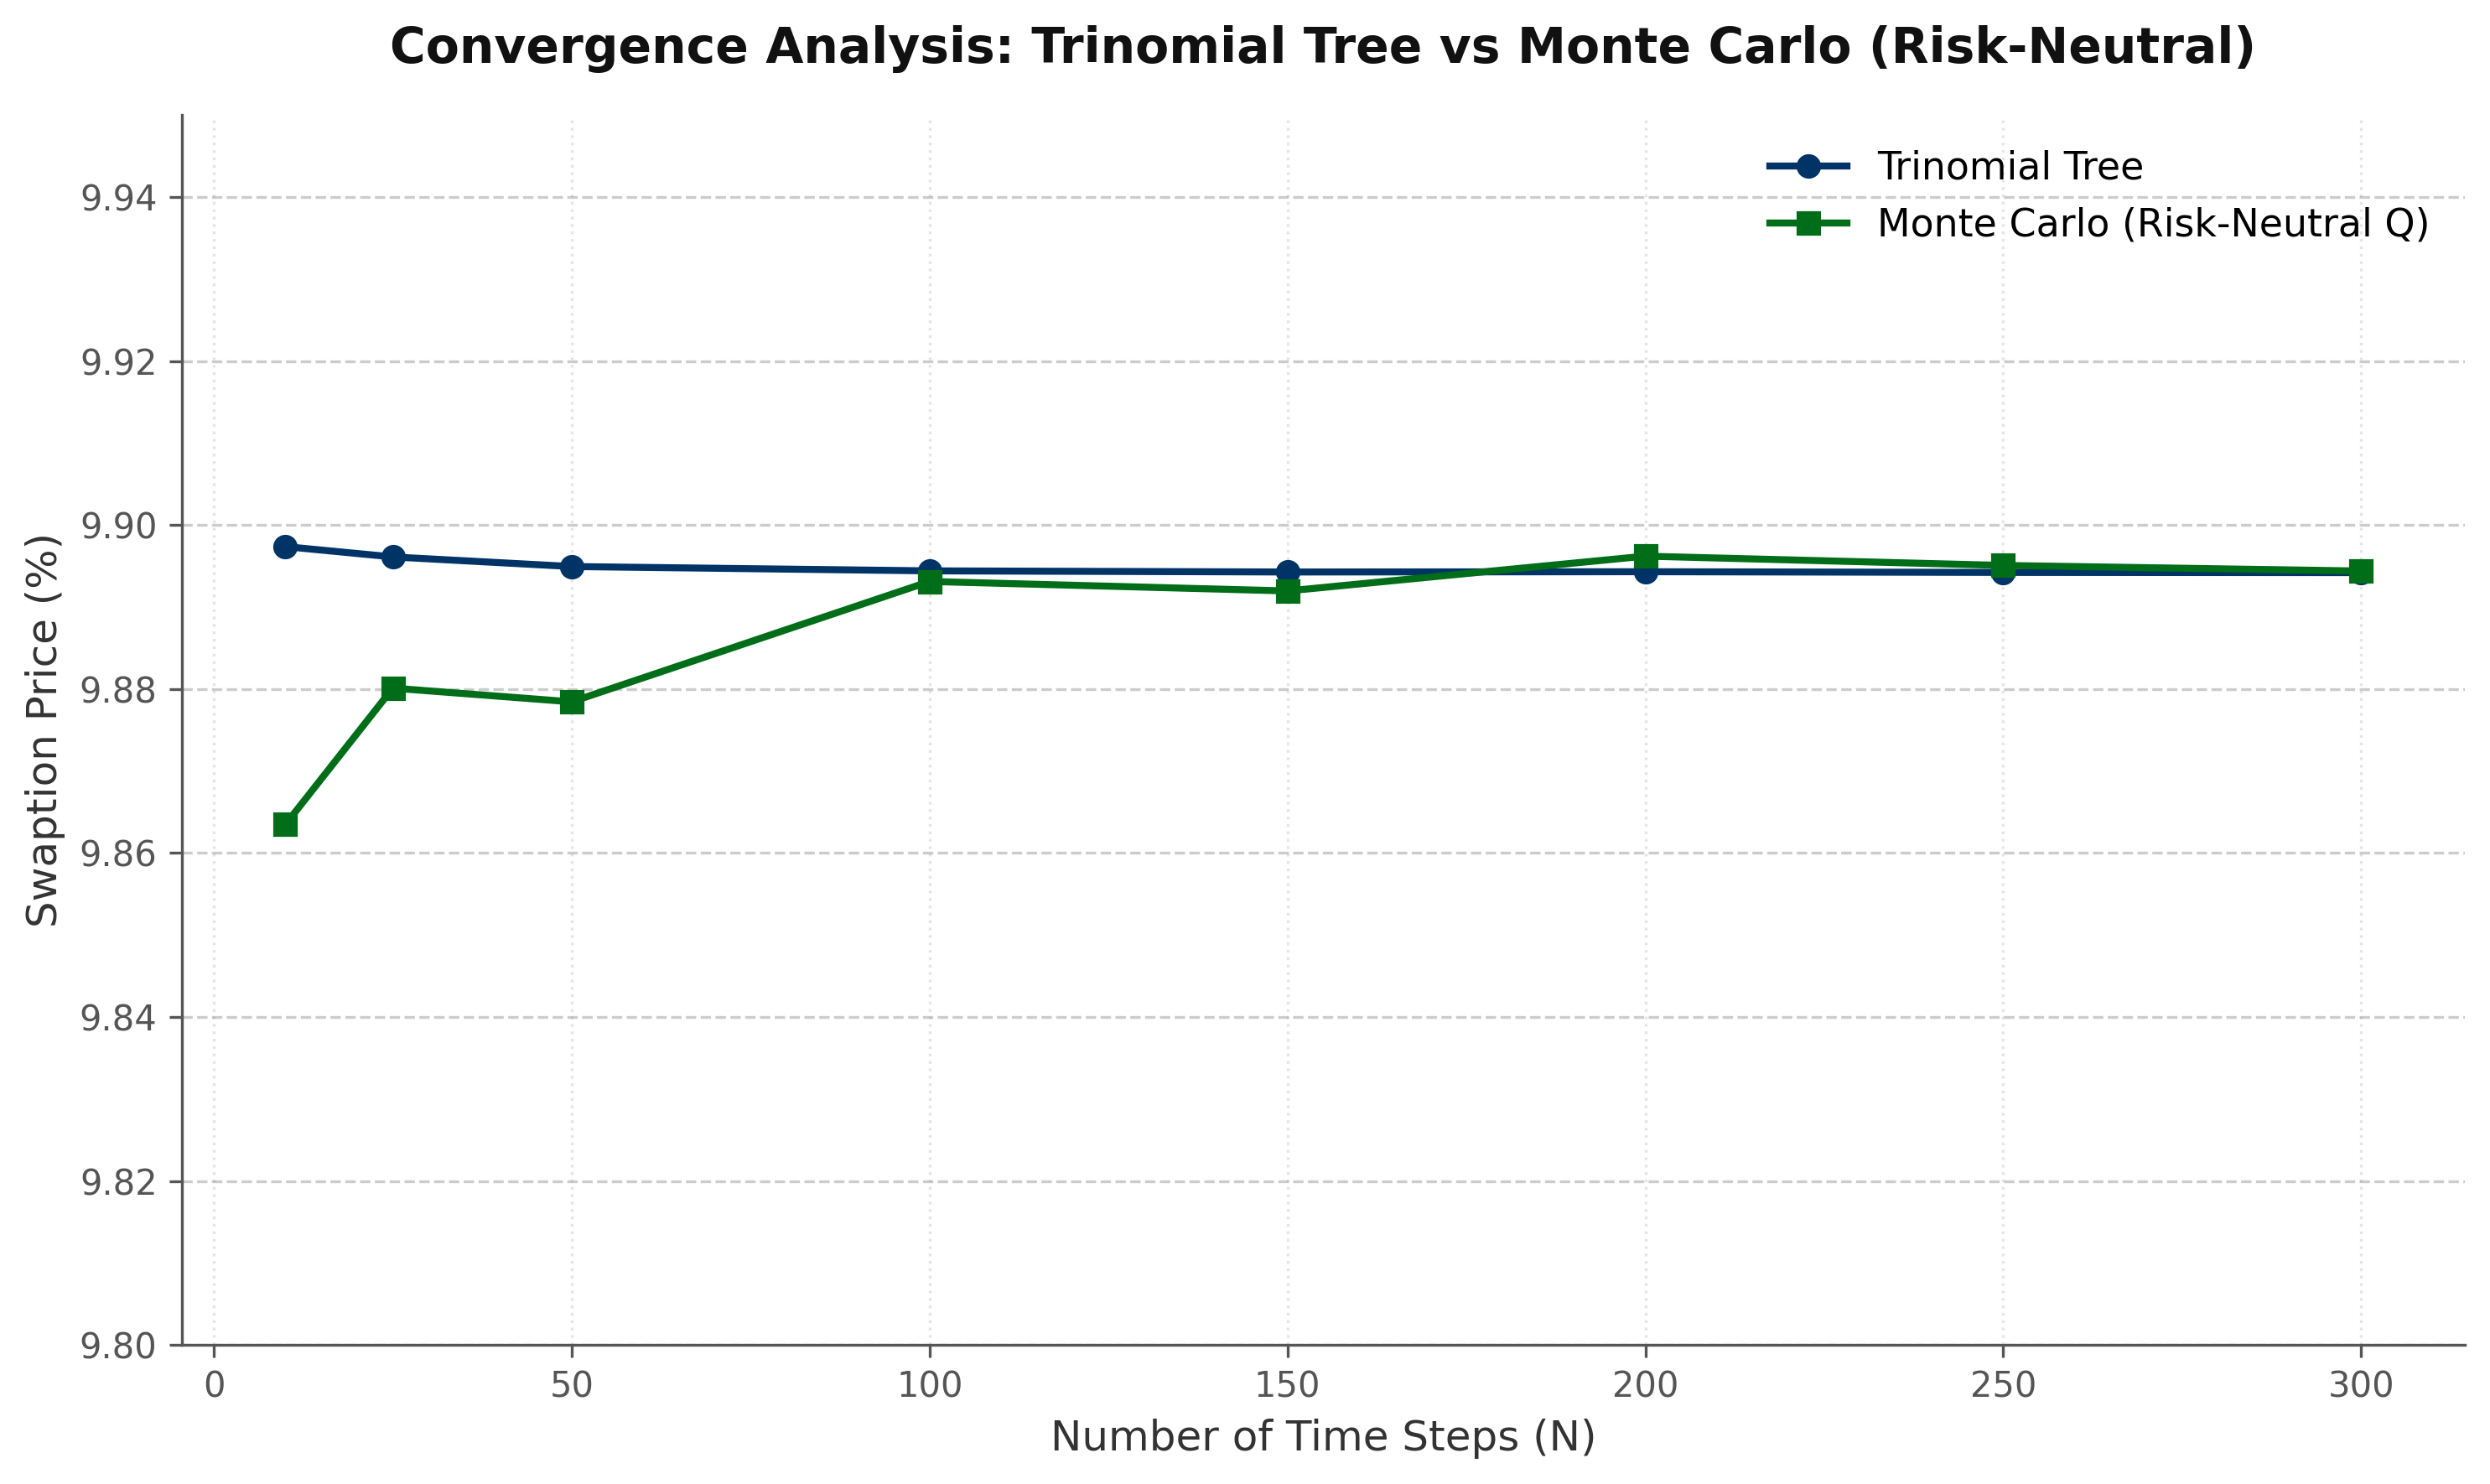

In [28]:
np.random.seed(42)
N_grid = [10, 25, 50, 100, 150, 200, 250, 300]
tree_p, mc_p, tree_t, mc_t = run_convergence_analysis_Q(N_grid, 1000000, 2.0, 10, 0.02, a_hat, sigma_hat, beta0, beta1, beta2, beta3, tau1, tau2)

Both methods successfully converge toward a consensus price of approximately 9.894%, but they exhibit distinctly different convergence behaviors:

The trinomial tree demonstrates remarkable stability almost immediately. Even with a very coarse grid ($N \approx 10$), the price is already extremely close to the final converged value. As $N$ increases up to 300, the price remains essentially flat. This indicates that the tree method does not suffer from significant discretization error here and requires very few steps to provide an accurate valuation.

For the Monte Carlo approach under the risk-neutral measure $\mathbb{Q}$, the time discretization step is $\Delta t = \frac{T}{N}$. At lower time steps ($N < 100$, meaning a larger $\Delta t$), the simulation noticeably underprices the swaption. This initial divergence is a classic symptom of time discretization bias introduced by the stepping scheme (Euler) used to simulate the underlying rates. As the grid becomes finer ($N \ge 150$), this bias diminishes. The Monte Carlo prices jump up and tightly track the trinomial tree, confirming both methods are evaluating the exact same theoretical expectation.

The analysis confirms theoretical expectations. The trinomial tree is highly efficient and accurate even with a coarse grid, making it the superior method for this low-dimensional problem. Conversely, the Monte Carlo simulation requires a much finer time grid to reliably eliminate discretization bias.

### **3.3. Sensitivity Analysis to the Mean-reversion Parameter $a$**

In this section, we perform a sensitivity analysis to the mean-reversion parameter $a$.

In [29]:
def analyze_a_sensitivity(a_values, N, T, tenor, K, sigma, b0, b1, b2, b3, t1, t2):
    prices_bps = []
    
    for a_test in a_values:
        p = build_hw_tree_swaption(N, T, tenor, K, a_test, sigma, b0, b1, b2, b3, t1, t2)
        prices_bps.append(p * 10000)
        
    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
    color_line = '#003366'
    ax1.plot(a_values, prices_bps, marker='o', markersize=5, linestyle='-', linewidth=2, color=color_line)
    
    ax1.set_xlabel('Mean-Reversion Parameter (a)', fontsize=12, fontweight='500', color='#333333')
    ax1.set_ylabel('Swaption Price (bps)', fontsize=12, fontweight='500', color='#333333')
    ax1.set_title('Sensitivity of Swaption Price to Mean-Reversion (a)', 
                  fontsize=14, fontweight='bold', color='#111111', pad=15)
    
    ax1.grid(True, axis='y', linestyle='--', color='gray', alpha=0.4)
    ax1.grid(True, axis='x', linestyle=':', color='gray', alpha=0.2)
    
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color('#555555')
    ax1.spines['bottom'].set_color('#555555')
    ax1.tick_params(axis='both', colors='#555555', labelsize=10)
    ax1.ticklabel_format(useOffset=False, style='plain', axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return prices_bps

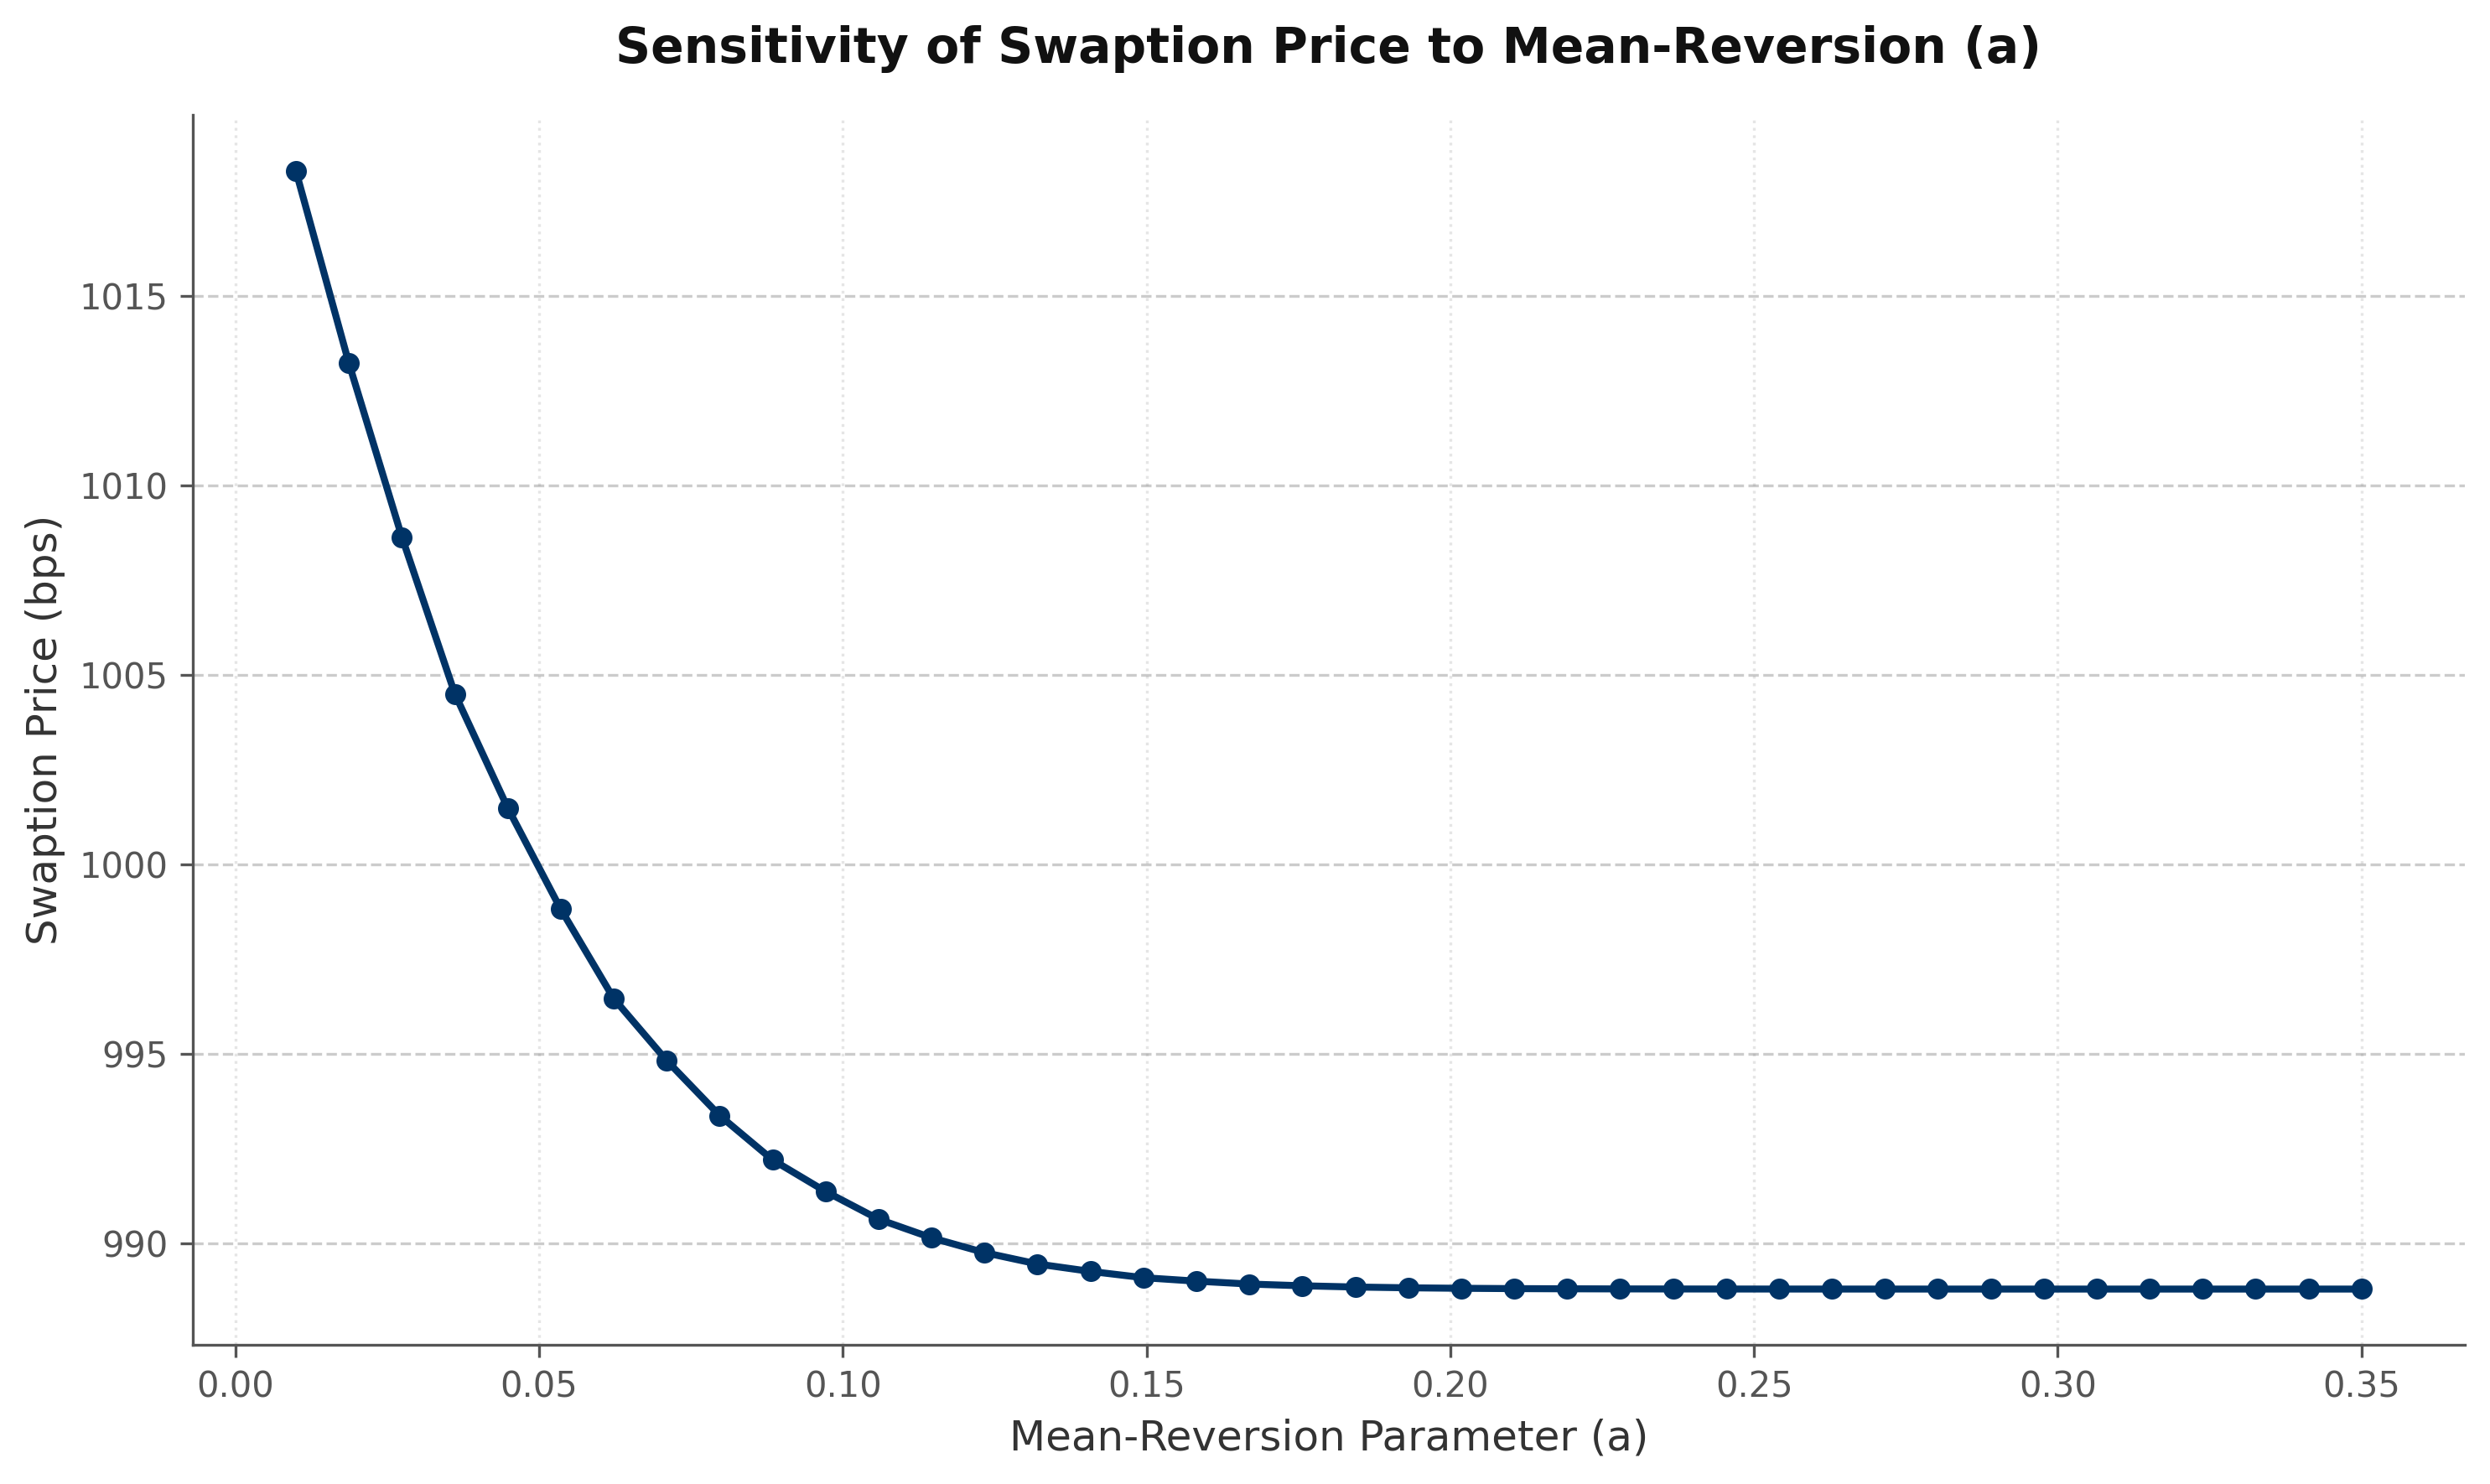

In [30]:
a_grid = np.linspace(0.01, 0.35, 40)
prices_a = analyze_a_sensitivity(a_grid, 100, 2.0, 10, 0.02, sigma_hat, beta0, beta1, beta2, beta3, tau1, tau2)

The graph above illustrates the sensitivity of the swaption premium (in basis points) to the mean-reversion parameter ($a$) within the Hull-White one-factor model. There is a pronounced, non-linear inverse relationship between the mean-reversion parameter and the swaption price. 

Recall that the parameter $a$ determines the speed at which the short rate $r_t$ is pulled back toward its time-dependent mean level $\theta(t)$. As $a$ increases, the price of the swaption significantly decreases. A stronger mean-reversion speed restricts the diffusion of interest rates over time, effectively reducing the overall variance of future rates. Because the underlying forward swap rate becomes less volatile, the optionality is worth less. Higher mean reversion dampens future rate volatility, leading to cheaper options.

## **4. Critical Analysis**

### **4.1. The assumption that $(a, \sigma)$ are identical under $\mathbb{P}$ and $\mathbb{Q}$**

In this project, we assumed that the volatility $\sigma$ and the mean-reversion speed $a$ remain invariant under a change of probability measure.

A fundamental limitation of the calibration approach used in this project is the reliance on historical rate time series. By estimating the Hull-White parameters $(a, \sigma)$ using historical data, we are calibrating the model under the real-world (or physical) probability measure $\mathbb{P}$. However, the valuation of derivatives like swaptions must be performed under the risk-neutral measure $\mathbb{Q}$.

Assuming that the parameters $a$ and $\sigma$ are perfectly identical under both measures ($\mathbb{P} \equiv \mathbb{Q}$) introduces distinct theoretical and practical impacts:

From a strictly mathematical standpoint (via Girsanov's Theorem), the instantaneous volatility of a diffusion process is invariant under a change of equivalent martingale measures. Therefore, assuming $\sigma_{\mathbb{P}} = \sigma_{\mathbb{Q}}$ is theoretically sound. In reality, the historical volatility realized in the physical market ($\sigma_{\mathbb{P}}$) rarely matches the implied volatility priced into derivatives ($\sigma_{\mathbb{Q}}$). Market implied volatility incorporates forward-looking expectations, supply/demand imbalances, and liquidity premiums. By using historical $\sigma$, our model fails to capture the market's forward-looking view of rate turbulence, often resulting in systematically underpriced or overpriced options relative to the prevailing market.

Unlike volatility, the drift of a stochastic process explicitly changes when moving from $\mathbb{P}$ to $\mathbb{Q}$. This adjustment is driven by the **market price of interest rate risk**, often denoted as $\lambda$. Under $\mathbb{P}$, the short rate dynamics are:
$$dr_t = (\theta^{\mathbb{P}}(t) - a_{\mathbb{P}} r_t)dt + \sigma dW_t^{\mathbb{P}}$$
When shifting to $\mathbb{Q}$, the standard approach adjusts the drift via $\lambda$, which directly alters the effective mean-reversion speed and level. Assuming $a_{\mathbb{P}} = a_{\mathbb{Q}}$ implicitly assumes a very specific, and often completely unrealistic, structure for the market price of risk (e.g., assuming investors require zero risk premium for holding long-term bonds). Because $a$ controls the dampening of forward rate volatility, getting it wrong has severe consequences for long-dated instruments. By forcing the risk-neutral mean reversion to equal the historical mean reversion, the model completely ignores the term premium embedded in the yield curve. This leads to a mis-specification of the forward volatility term structure, causing the model to misprice.

### **4.2. Historical Volatility vs Implied Volatility**

Historical volatility is backward-looking, measuring how interest rates have evolved over a past time window. While it captures realized fluctuations, it does not account for upcoming events or market expectations, such as central bank meetings or macroeconomic announcements.

Implied volatility, in contrast, is forward-looking. It is inferred from current market prices of options and reflects the market’s collective expectations of future volatility.

Relying solely on historical volatility for derivative pricing can be problematic, as it may lead to inconsistencies with observed market prices or even potential arbitrage opportunities. In practice, implied volatility is used for pricing, ensuring that model prices align with the market and accurately reflect prevailing expectations.

### **4.3. Calibration Using Market Prices (Swaptions)**

If market swaption prices were available, the calibration paradigm would shift fundamentally from backward-looking historical data to forward-looking market expectations. Instead of relying on time-series estimation techniques such as Maximum Likelihood Estimation (MLE) or AR(1) regressions on historical short rates, the Hull-White model parameters $(a, \sigma)$ would be calibrated directly to the prices of actively traded liquid derivatives. 

The goal is to minimize the squared error between observed market prices and model-generated prices. We define a loss function to optimize:
   $$\min_{a, \sigma} \sum_{i=1}^{N} w_i \left( P_i^{\text{Market}} - P_i^{\text{HW}}(a, \sigma) \right)^2$$
   * $P_i^{\text{Market}}$: The market price of the $i$-th swaption
   * $P_i^{\text{HW}}(a, \sigma)$: The theoretical price generated by the Hull-White model for a given mean reversion and volatility.
   * $w_i$: Optional weights (often vega weights) applied to prioritize fitting the most liquid instruments.

Because the Hull-White pricing formula is non-linear with respect to its parameters, a non-linear least-squares optimization algorithm is used to search the parameter space for the optimal $(a, \sigma)$ pair.